## Eco-Risk Alpha: Measuring the Green Discount in Counterparty **CVA**

INSTALLING  NECESSARY PACKAGES

In [197]:
#Importing basic data packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.inspection import PartialDependenceDisplay
#for linear regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_white, het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#for machine learning
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold, LeaveOneOut,cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay



### Save the relevant data

Read and save the main dataset, make a copy of it for cleaning, show basic information about it

In [198]:
companies= pd.read_csv(r"C:\Users\alans\OneDrive\Desktop\berlin\report\green_project_students_data\raw_companies_data.csv", index_col=0)

ZERO_RATES_DF= pd.read_csv(r"C:\Users\alans\OneDrive\Desktop\berlin\report\green_project_students_data\zero_rates.csv", index_col=0)
EE_PROFILE_DF= pd.read_csv(r"C:\Users\alans\OneDrive\Desktop\berlin\report\green_project_students_data\synthetic_irs_ee_profile.csv", index_col=0)

In [199]:
ZERO_RATES_DF

,Zero_Rate
Maturity,
0.5,2.00%
1.0,2.05%
2.0,2.10%
3.0,2.15%
4.0,2.20%
5.0,2.25%


In [200]:
companies_data =companies. copy()

In [201]:
companies_data.head()

,Company,Sector,Region,ESG_Score,E_Score,S_Score,G_Score,Carbon_Intensity,Market_Cap,Total_Assets,Debt_to_Equity,EBITDA_Margin,Leverage_Ratio,CDS_Spread_5Y
1,Company_1,technology,North America,52.4724,88.1751,31.8858,84.4960,NaN,30150.4403,12232.9808,1.5591,8.6093,1.5766,34.0068
2,Company_2,technology,North America,52.4724,88.1751,31.8858,84.4960,NaN,30150.4403,12232.9808,1.5591,8.6093,1.5766,34.0068
3,Company_3,Consumer Goods,north america,87.0429,76.5080,68.1846,44.3737,71.0350,39124.6751,107208.2171,2.5838,36.5894,1.1610,38.1718
4,Company_4,FINANCE,Europe,73.9196,86.3699,48.8614,38.6937,90.4072,85262.5305,109045.7541,2.0102,22.6838,0.9060,61.7321
5,Company_5,Technology,ASIA,65.9195,83.6896,60.5142,59.3672,274.6385,32375.2785,128211.1205,0.5725,33.9260,1.8221,29.9490


In [202]:
companies_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1 to 60
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           60 non-null     object 
 1   Sector            60 non-null     object 
 2   Region            60 non-null     object 
 3   ESG_Score         54 non-null     float64
 4   E_Score           60 non-null     float64
 5   S_Score           60 non-null     float64
 6   G_Score           60 non-null     float64
 7   Carbon_Intensity  52 non-null     float64
 8   Market_Cap        53 non-null     float64
 9   Total_Assets      59 non-null     float64
 10  Debt_to_Equity    59 non-null     float64
 11  EBITDA_Margin     59 non-null     float64
 12  Leverage_Ratio    59 non-null     float64
 13  CDS_Spread_5Y     59 non-null     float64
dtypes: float64(11), object(3)
memory usage: 7.0+ KB


Fix 'Sector' and 'Region' formatting and replace aliases

In [203]:
display(pd.unique(companies_data.Sector))
display(pd.unique(companies_data.Region))

array(['technology', 'Consumer Goods', 'FINANCE', 'Technology',
       'Utilities', 'Finance', 'Healthcare', 'Industrials', 'Energy',
       'Tech'], dtype=object)

array(['North America', 'north america', 'Europe', 'ASIA',
       'South America', 'Asia'], dtype=object)

In [204]:
# Sectors
companies_data['Sector'] = companies_data['Sector'].str.capitalize()
display(pd.unique(companies_data.Sector))

#Replace Tech with Technology
companies_data['Sector'] = ['Technology' if sector == 'Tech' else sector for sector in companies_data['Sector']]
display(pd.unique(companies_data.Sector))

array(['Technology', 'Consumer goods', 'Finance', 'Utilities',
       'Healthcare', 'Industrials', 'Energy', 'Tech'], dtype=object)

array(['Technology', 'Consumer goods', 'Finance', 'Utilities',
       'Healthcare', 'Industrials', 'Energy'], dtype=object)

In [205]:
# Regions
companies_data['Region'] = companies_data['Region'].str.title()
display(pd.unique(companies_data.Region))

array(['North America', 'Europe', 'Asia', 'South America'], dtype=object)

Plot the number of companies per Sector and per Region

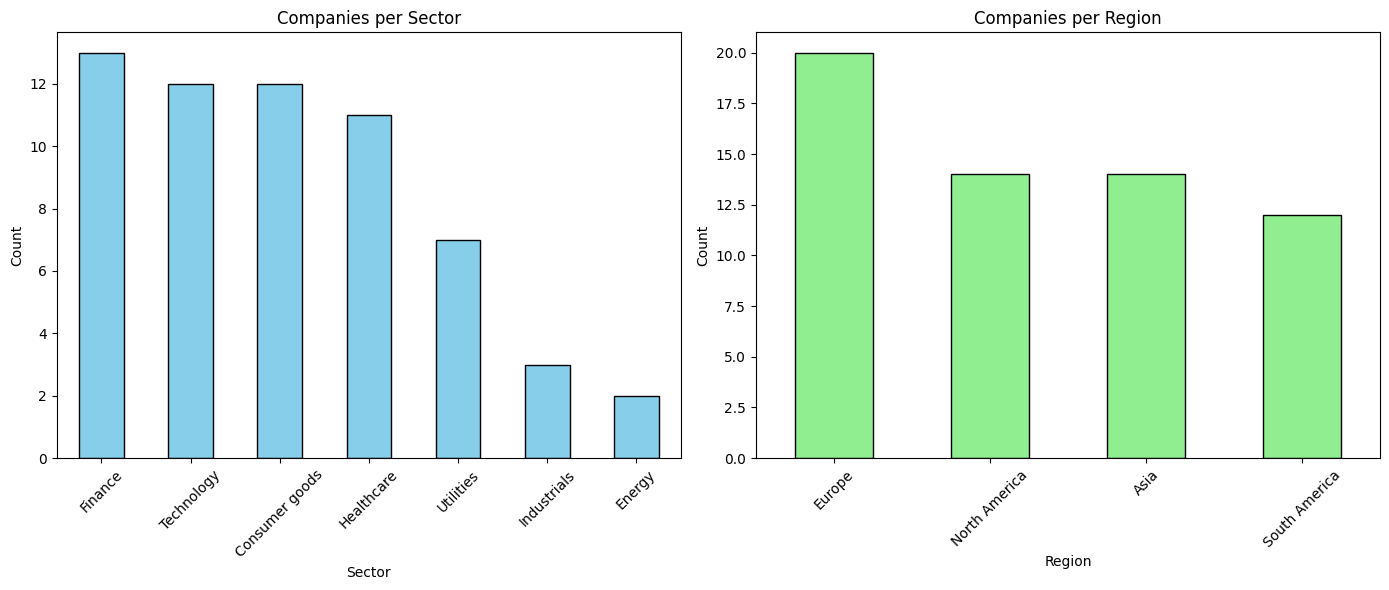

In [206]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

companies_data["Sector"].value_counts().plot(
    kind="bar", ax=axes[0], color="skyblue", edgecolor="black"
)
axes[0].set_title("Companies per Sector")
axes[0].set_xlabel("Sector")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

companies_data["Region"].value_counts().plot(
    kind="bar", ax=axes[1], color="lightgreen", edgecolor="black"
)
axes[1].set_title("Companies per Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Replace missing values for 'ESG_Score'

In [207]:
# keep track of which companies have missing values for ESG
print('Companies with missing ESG values')
print(companies_data.loc[companies_data['ESG_Score'].isna(), ['Company']])

Companies with missing ESG values
       Company
15  Company_15
20  Company_20
21  Company_21
33  Company_33
38  Company_38
39  Company_39



ESG imputation complete.
ESG_Score NA before: 6
ESG_Score NA after:  0


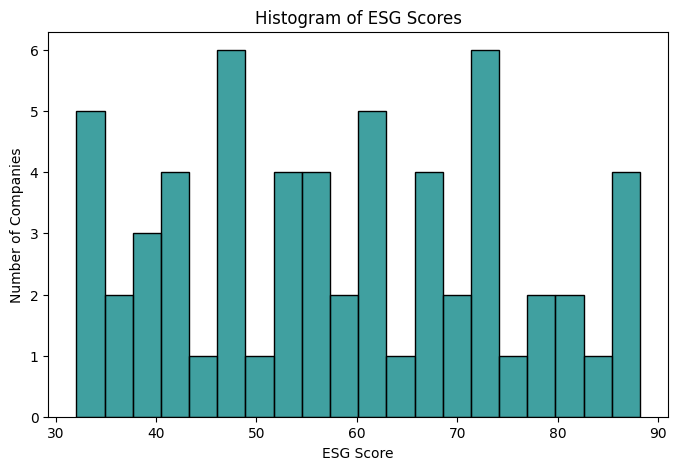

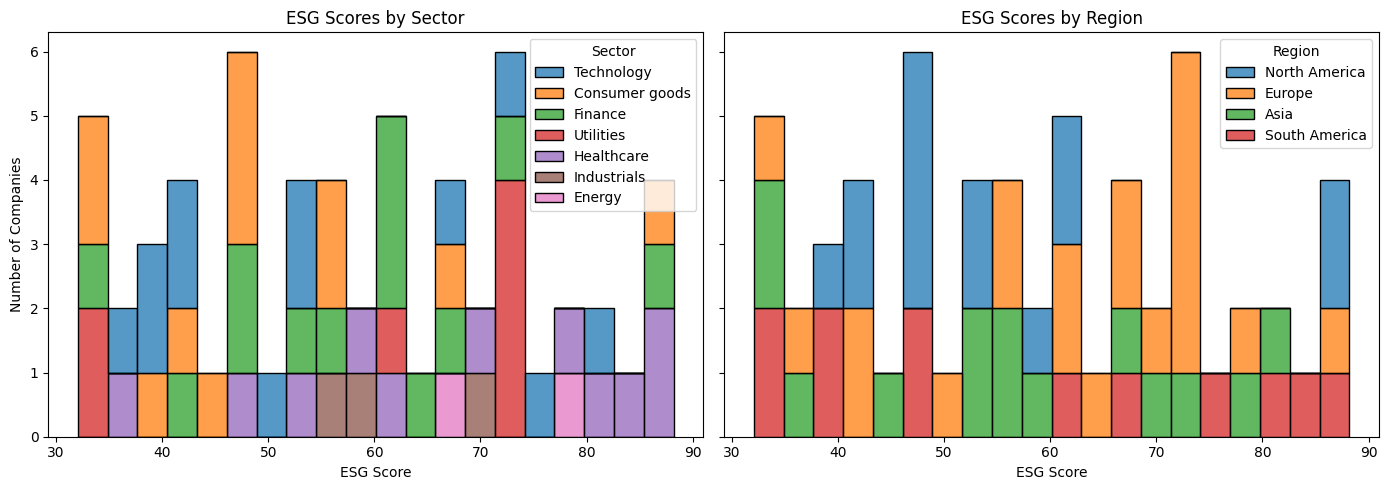

In [208]:
# Count NAs before
na_before = companies_data['ESG_Score'].isna().sum()

# Fill missing ESG_Score with weighted average of E, S, G
companies_data['ESG_Score'] = companies_data['ESG_Score'].fillna(
    0.5 * companies_data['E_Score'] +
    0.3 * companies_data['S_Score'] +
    0.2 * companies_data['G_Score']
)

# Count NAs after
na_after = companies_data['ESG_Score'].isna().sum()

print("\nESG imputation complete."
      f"\nESG_Score NA before: {na_before}"
      f"\nESG_Score NA after:  {na_after}")

plt.figure(figsize=(8,5))
sns.histplot(data=companies_data, x="ESG_Score", bins=20, color="teal", edgecolor="black")
plt.title("Histogram of ESG Scores")
plt.xlabel("ESG Score")
plt.ylabel("Number of Companies")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# ESG by Sector
sns.histplot(data=companies_data, x="ESG_Score", hue="Sector",
             multiple="stack", bins=20, ax=axes[0])
axes[0].set_title("ESG Scores by Sector")
axes[0].set_xlabel("ESG Score")
axes[0].set_ylabel("Number of Companies")

# ESG by Region
sns.histplot(data=companies_data, x="ESG_Score", hue="Region",
             multiple="stack", bins=20, ax=axes[1])
axes[1].set_title("ESG Scores by Region")
axes[1].set_xlabel("ESG Score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


Through inspection of the dataset we find an entry, namely 'Company_21' that has many missing values.
Instead of filling in each value with medians, we choose to drop this entry, so as not to have a mostly synthetic entry and to not reinforce medians too much.

In [209]:
# Show the entry 'Company_21'
print(companies_data[companies_data["Company"] == "Company_21"])

# Drop the row where Company == "Company_21"
companies_data = companies_data[companies_data['Company'] != "Company_21"]

# Reset row indices
companies_data = companies_data.reset_index(drop=True)
companies_data.index = companies_data.index + 1

       Company   Sector  Region  ESG_Score  E_Score  S_Score  G_Score  \
21  Company_21  Finance  Europe   55.21031  55.5832  36.6031  82.1889   

    Carbon_Intensity  Market_Cap  Total_Assets  Debt_to_Equity  EBITDA_Margin  \
21               NaN         NaN           NaN             NaN            NaN   

    Leverage_Ratio  CDS_Spread_5Y  
21             NaN            NaN  


Look for duplicates to eliminate

In [210]:
# Define columns to check (ignore Company and index column)
cols_to_check = companies_data.columns.difference(["Company", "Unnamed: 0"])

# Find duplicate groups (ignoring "Company")
dupe_groups = (
    companies_data.groupby(list(cols_to_check), dropna=False)
    .agg(
        n_in_group=('Company', 'count'),
        companies_in_group=('Company', lambda x: ", ".join(x))
    )
    .reset_index()
)

# Keep only groups with duplicates
dupe_summary = dupe_groups[dupe_groups['n_in_group'] > 1]

print("\nDuplicate patterns found (ignoring Company):")
print(dupe_summary[['n_in_group', 'companies_in_group']])

# Total rows to drop = all but the first of each group
total_to_drop = int((dupe_summary['n_in_group'] - 1).sum())
print("\nTotal rows to be deleted:", total_to_drop)

# Drop duplicates (keep first per group)
companies_data = companies_data.drop_duplicates(subset=cols_to_check, keep="first").reset_index(drop=True)
companies_data.index = companies_data.index + 1


Duplicate patterns found (ignoring Company):
    n_in_group                              companies_in_group
7            2                          Company_36, Company_37
18           2                          Company_59, Company_60
25           4  Company_11, Company_12, Company_13, Company_14
27           2                            Company_1, Company_2
34           2                          Company_57, Company_58
39           2                          Company_25, Company_26
42           2                          Company_47, Company_48

Total rows to be deleted: 9


In [211]:
companies_data

,Company,Sector,Region,ESG_Score,E_Score,S_Score,G_Score,Carbon_Intensity,Market_Cap,Total_Assets,Debt_to_Equity,EBITDA_Margin,Leverage_Ratio,CDS_Spread_5Y
1,Company_1,Technology,North America,52.47240,88.1751,31.8858,84.4960,NaN,30150.4403,12232.9808,1.5591,8.6093,1.5766,34.0068
2,Company_3,Consumer goods,North America,87.04290,76.5080,68.1846,44.3737,71.0350,39124.6751,107208.2171,2.5838,36.5894,1.1610,38.1718
3,Company_4,Finance,Europe,73.91960,86.3699,48.8614,38.6937,90.4072,85262.5305,109045.7541,2.0102,22.6838,0.9060,61.7321
4,Company_5,Technology,Asia,65.91950,83.6896,60.5142,59.3672,274.6385,32375.2785,128211.1205,0.5725,33.9260,1.8221,29.9490
5,Company_6,Consumer goods,North America,39.36110,65.8740,84.4540,89.1390,201.6073,17779.7819,145766.0841,0.3046,16.2017,0.3113,27.6713
6,Company_7,Technology,South America,39.35970,85.3125,44.9575,44.5233,52.2993,56123.3250,195218.7117,1.9630,36.3433,1.0360,65.1008
7,Company_8,Utilities,Asia,33.48500,35.3096,54.6230,70.3281,NaN,NaN,104227.4690,0.1769,18.6221,0.1216,18.5712
8,Company_9,Technology,Asia,81.97060,41.7590,75.3331,75.6972,215.8754,69906.9499,65945.3816,1.7987,5.3793,0.9905,27.4909
9,Company_10,Finance,Europe,66.06690,32.7136,43.7279,44.2583,51.2654,57436.0558,159446.8666,2.8267,36.6884,0.2070,8.1874
10,Company_11,Utilities,Europe,72.48440,49.5198,34.6188,73.6930,90.2020,10620.4729,55624.7857,1.7689,8.1950,0.3258,29.8871


Boxplots to identify potential outliers

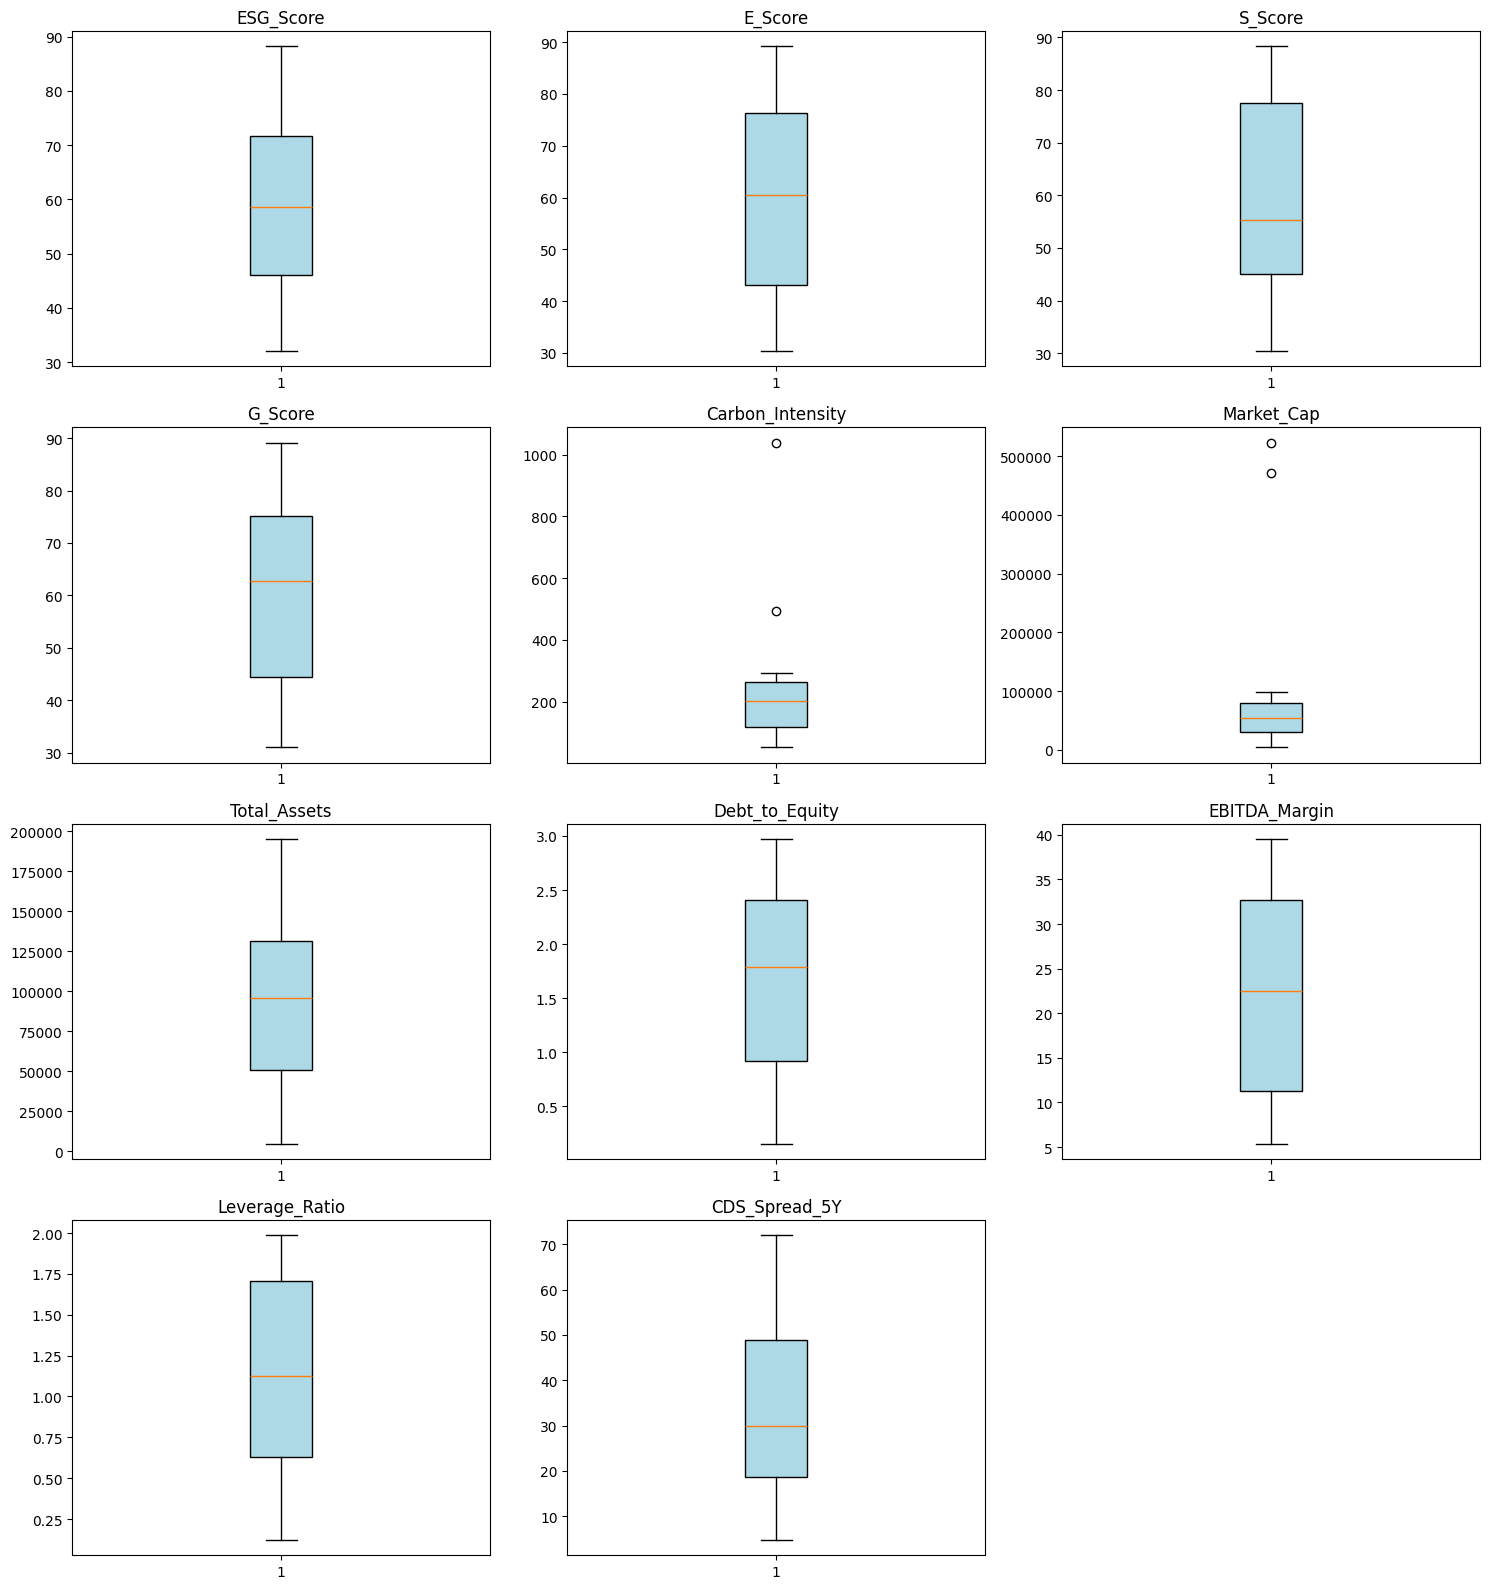

In [212]:
num_cols = companies_data.select_dtypes(include=np.number).columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(companies_data[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightblue"))
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
#plt.show()   # uncomment this line to see the boxplots of all the variables


Outliers in Carbon_Intensity:
       Company          Sector         Region  Carbon_Intensity
30  Company_36  Consumer goods  South America         1038.9233
35  Company_42      Healthcare         Europe          494.0537

Outliers in Market_Cap:
       Company          Sector         Region   Market_Cap
14  Company_18  Consumer goods  North America  523146.3558
37  Company_44  Consumer goods  North America  470942.0380


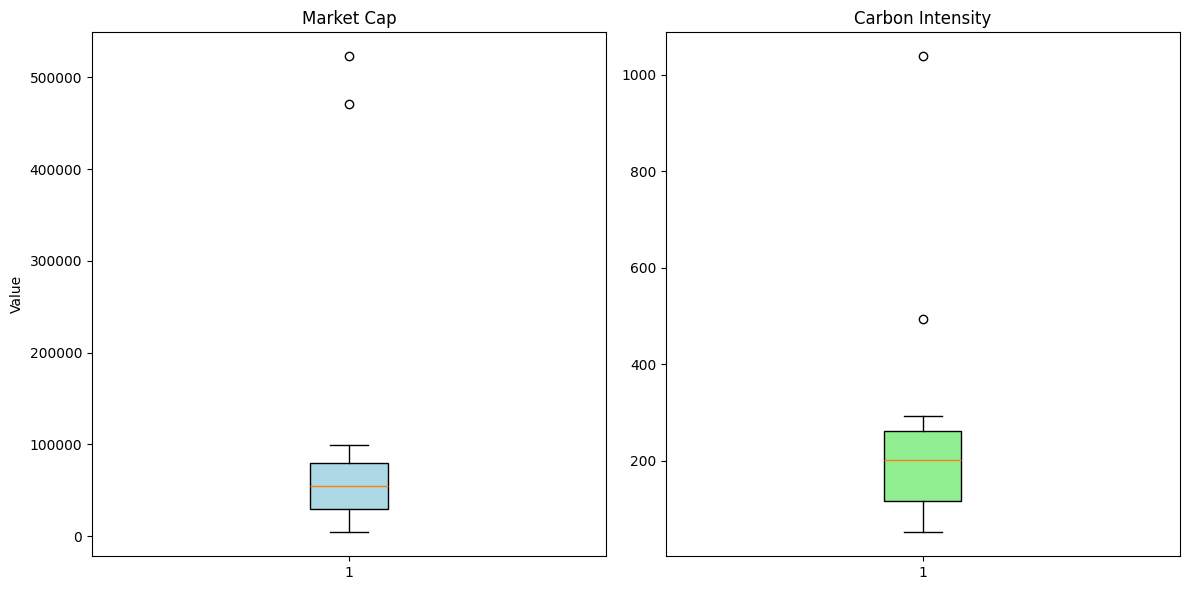

In [213]:
# print out the outliers
for col in companies_data.select_dtypes(include=np.number).columns:
    Q1 = companies_data[col].quantile(0.25)
    Q3 = companies_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    outliers = companies_data[(companies_data[col] < lower) | (companies_data[col] > upper)]
    if not outliers.empty:
        print(f"\nOutliers in {col}:")
        print(outliers[["Company", "Sector", "Region", col]])



fig, axes = plt.subplots(1, 2, figsize=(12,6))

# --- Boxplot for Market Cap ---
axes[0].boxplot(companies_data["Market_Cap"].dropna(),
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"))
axes[0].set_title("Market Cap")
axes[0].set_ylabel("Value")

# --- Boxplot for Carbon Intensity ---
axes[1].boxplot(companies_data["Carbon_Intensity"].dropna(),
                patch_artist=True,
                boxprops=dict(facecolor="lightgreen"))
axes[1].set_title("Carbon Intensity")

plt.tight_layout()
plt.show()


Handling the NA logic
If there are

In [214]:
# NAs before
na_counts = companies_data.isna().sum().astype(int).reset_index()
na_counts.columns = ["column", "na_count"]
print(na_counts)

# choose numeric columns to impute (exclude identifiers)
num_cols = companies_data.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    missing_mask = companies_data[col].isna()
    if not missing_mask.any():
        continue

    # Precompute sector medians and per-row fill candidates
    sector_medians = companies_data.groupby("Sector")[col].median()
    fill_candidates = companies_data.groupby("Sector")[col].transform("median")

    print(f"\nColumn: {col}")
    print("Companies with NA in this column:")
    print(companies_data.loc[missing_mask, ["Company", "Sector", col]])

    # Summarize which median each sector will use
    missing_rows = companies_data.loc[missing_mask, ["Company", "Sector", col]]
    sec_counts = missing_rows.groupby("Sector").size().rename("rows_with_na")
    sec_meds = sector_medians.reindex(sec_counts.index)
    sec_summary = pd.concat([sec_counts, sec_meds.rename("median_used")], axis=1)
    print("\nSector-wise medians used:")
    print(sec_summary)

    # Impute only where a sector median exists
    to_impute = missing_mask & fill_candidates.notna()
    companies_data.loc[to_impute, col] = fill_candidates[to_impute]

    print(f"---- Imputed {to_impute.sum()} row(s); "
          f"{missing_mask.sum() - to_impute.sum()} left as NA (no sector median) ----")



              column  na_count
0            Company         0
1             Sector         0
2             Region         0
3          ESG_Score         0
4            E_Score         0
5            S_Score         0
6            G_Score         0
7   Carbon_Intensity         5
8         Market_Cap         5
9       Total_Assets         0
10    Debt_to_Equity         0
11     EBITDA_Margin         0
12    Leverage_Ratio         0
13     CDS_Spread_5Y         0

Column: Carbon_Intensity
Companies with NA in this column:
       Company      Sector  Carbon_Intensity
1    Company_1  Technology               NaN
7    Company_8   Utilities               NaN
16  Company_20  Technology               NaN
32  Company_39  Healthcare               NaN
49  Company_57     Finance               NaN

Sector-wise medians used:
            rows_with_na  median_used
Sector                               
Finance                1    145.10170
Healthcare             1    192.24875
Technology             2  

In [215]:
# Final NA check
na_counts_after = companies_data.isna().sum().astype(int).reset_index()
na_counts_after.columns = ["column", "na_count"]
print("\nAfter imputation:")
print(na_counts_after)


After imputation:
              column  na_count
0            Company         0
1             Sector         0
2             Region         0
3          ESG_Score         0
4            E_Score         0
5            S_Score         0
6            G_Score         0
7   Carbon_Intensity         0
8         Market_Cap         0
9       Total_Assets         0
10    Debt_to_Equity         0
11     EBITDA_Margin         0
12    Leverage_Ratio         0
13     CDS_Spread_5Y         0


Now that we fixed the NaN logic, we can Log-transform the 2 features that had outliers and add these new columns to the dataset

In [216]:
# Columns to log-transform outliers-Market cap and Carbon Intensity
log_cols = ["Market_Cap", "Carbon_Intensity"]

# Apply log(1 + x) to handle skew and zero values
for col in log_cols:
    companies_data[f"log_{col}"] = np.log1p(companies_data[col])

# Check first rows of transformed data
print(companies_data[["Market_Cap", "log_Market_Cap",
                                "Carbon_Intensity", "log_Carbon_Intensity"]].head())

   Market_Cap  log_Market_Cap  Carbon_Intensity  log_Carbon_Intensity
1  30150.4403       10.313988          239.5639              5.482986
2  39124.6751       10.574534           71.0350              4.277152
3  85262.5305       11.353502           90.4072              4.515324
4  32375.2785       10.385181          274.6385              5.619090
5  17779.7819        9.785873          201.6073              5.311270


Display the clean dataset

In [217]:
display(companies_data)

,Company,Sector,Region,ESG_Score,E_Score,S_Score,G_Score,Carbon_Intensity,Market_Cap,Total_Assets,Debt_to_Equity,EBITDA_Margin,Leverage_Ratio,CDS_Spread_5Y,log_Market_Cap,log_Carbon_Intensity
1,Company_1,Technology,North America,52.47240,88.1751,31.8858,84.4960,239.56390,30150.44030,12232.9808,1.5591,8.6093,1.5766,34.0068,10.313988,5.482986
2,Company_3,Consumer goods,North America,87.04290,76.5080,68.1846,44.3737,71.03500,39124.67510,107208.2171,2.5838,36.5894,1.1610,38.1718,10.574534,4.277152
3,Company_4,Finance,Europe,73.91960,86.3699,48.8614,38.6937,90.40720,85262.53050,109045.7541,2.0102,22.6838,0.9060,61.7321,11.353502,4.515324
4,Company_5,Technology,Asia,65.91950,83.6896,60.5142,59.3672,274.63850,32375.27850,128211.1205,0.5725,33.9260,1.8221,29.9490,10.385181,5.619090
5,Company_6,Consumer goods,North America,39.36110,65.8740,84.4540,89.1390,201.60730,17779.78190,145766.0841,0.3046,16.2017,0.3113,27.6713,9.785873,5.311270
6,Company_7,Technology,South America,39.35970,85.3125,44.9575,44.5233,52.29930,56123.32500,195218.7117,1.9630,36.3433,1.0360,65.1008,10.935325,3.975923
7,Company_8,Utilities,Asia,33.48500,35.3096,54.6230,70.3281,236.62290,46528.96420,104227.4690,0.1769,18.6221,0.1216,18.5712,10.747852,5.470685
8,Company_9,Technology,Asia,81.97060,41.7590,75.3331,75.6972,215.87540,69906.94990,65945.3816,1.7987,5.3793,0.9905,27.4909,11.154935,5.379323
9,Company_10,Finance,Europe,66.06690,32.7136,43.7279,44.2583,51.26540,57436.05580,159446.8666,2.8267,36.6884,0.2070,8.1874,10.958445,3.956335
10,Company_11,Utilities,Europe,72.48440,49.5198,34.6188,73.6930,90.20200,10620.47290,55624.7857,1.7689,8.1950,0.3258,29.8871,9.270633,4.513077


### more plots

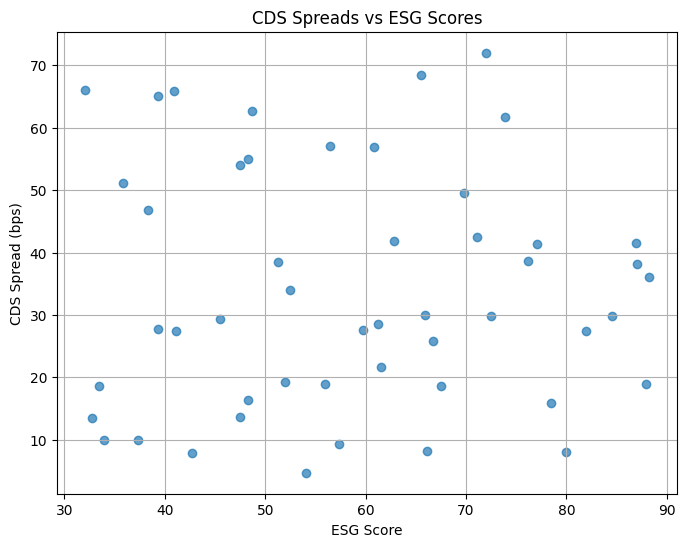

In [218]:
# investigate the relation between CDS spreads and ESG scores
plt.figure(figsize=(8, 6))
plt.scatter(companies_data['ESG_Score'], companies_data['CDS_Spread_5Y'], alpha=0.7)

plt.xlabel("ESG Score")
plt.ylabel("CDS Spread (bps)")
plt.title("CDS Spreads vs ESG Scores")
plt.grid(True)
plt.show()

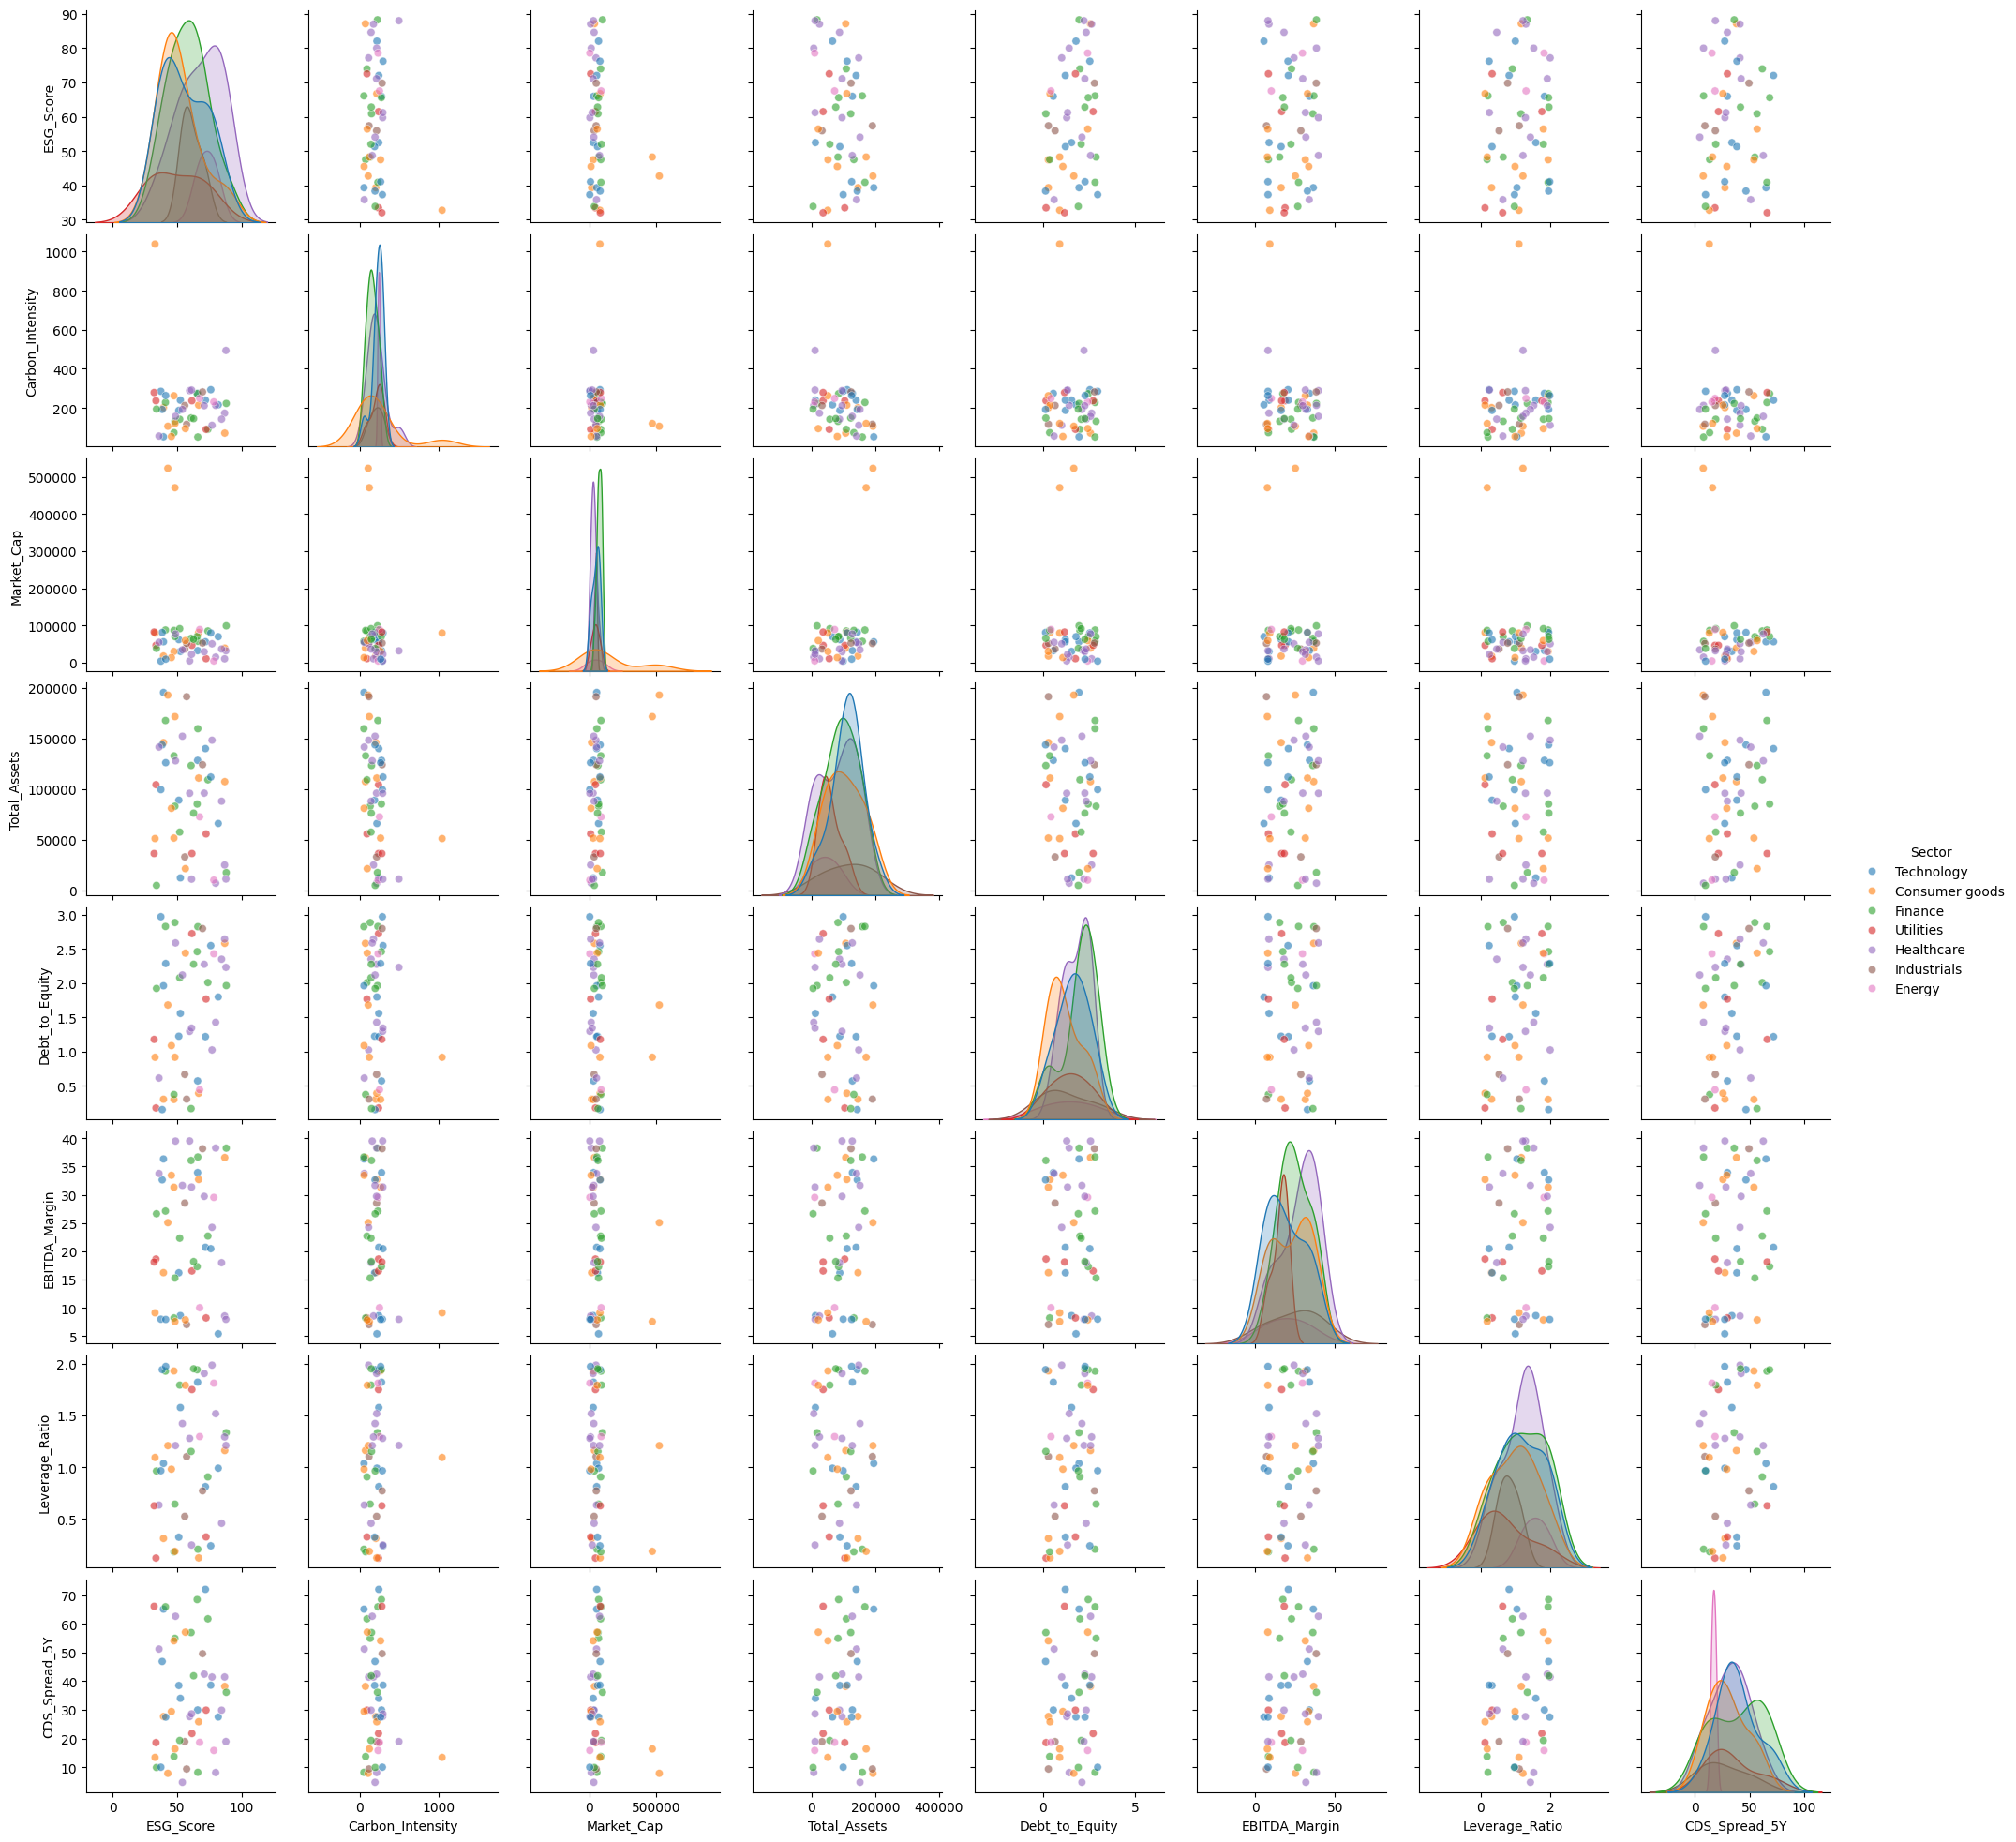

In [219]:
cols = [
    'ESG_Score',
    'Carbon_Intensity',
    'Market_Cap',
    'Total_Assets',
    'Debt_to_Equity',
    'EBITDA_Margin',
    'Leverage_Ratio',
    'CDS_Spread_5Y',
    'Sector'
]

sns.pairplot(companies_data[cols],
             hue="Sector",          # color points by Sector (categorical)
             diag_kind="kde",       # density plot on diagonal
             plot_kws={"alpha":0.6})  # transparency for scatter
plt.show()

Correlation heatmap of numeric variables.
Helps you see if, for example, higher market cap correlates with lower carbon intensity.

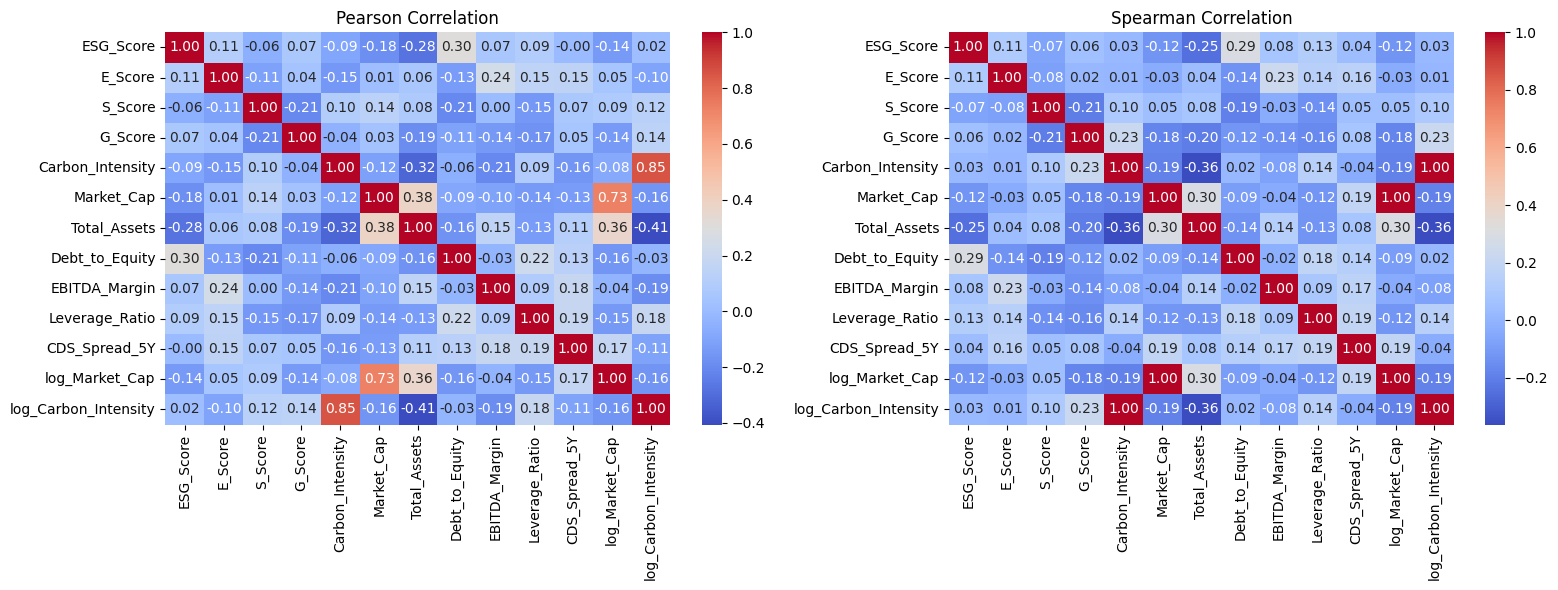

In [ ]:

# Pearson correlation
corr_pearson = companies_data.select_dtypes(include="number").corr(method="pearson")
#include into extensions possible as graph which we can explore
# Spearman correlation
corr_spearman = companies_data.select_dtypes(include="number").corr(method="spearman")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Pearson Correlation")

sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()




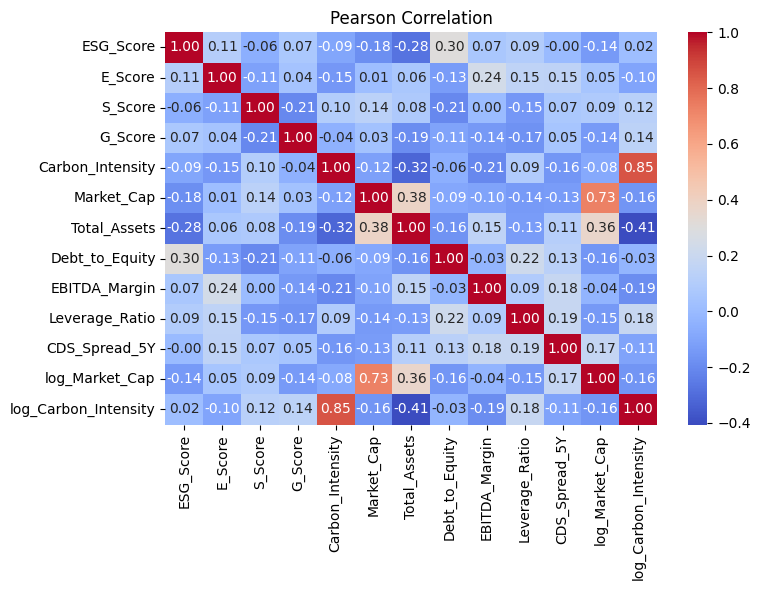

In [221]:
# Pearson correlation
corr_pearson = companies_data.select_dtypes(include="number").corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation")
plt.tight_layout()
plt.show()


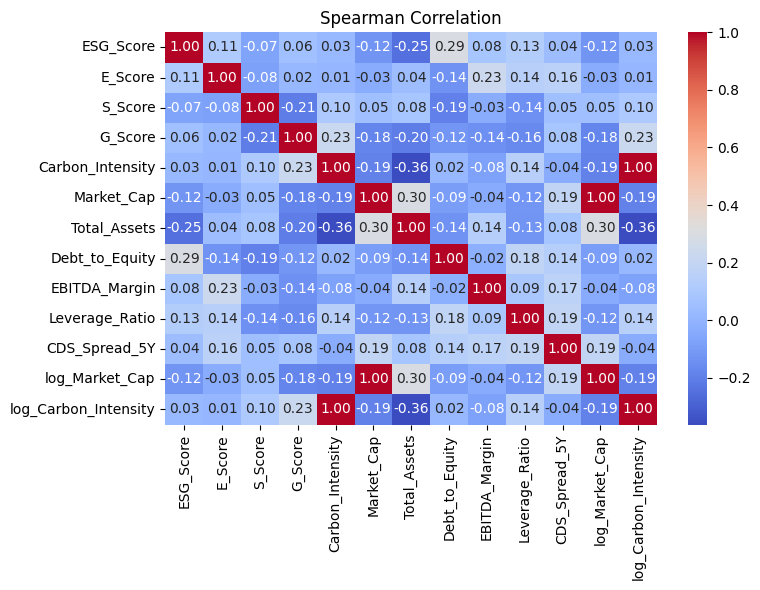

In [222]:
# Spearman correlation
corr_spearman = companies_data.select_dtypes(include="number").corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation")
plt.tight_layout()
plt.show()


Plot the distribution of the features

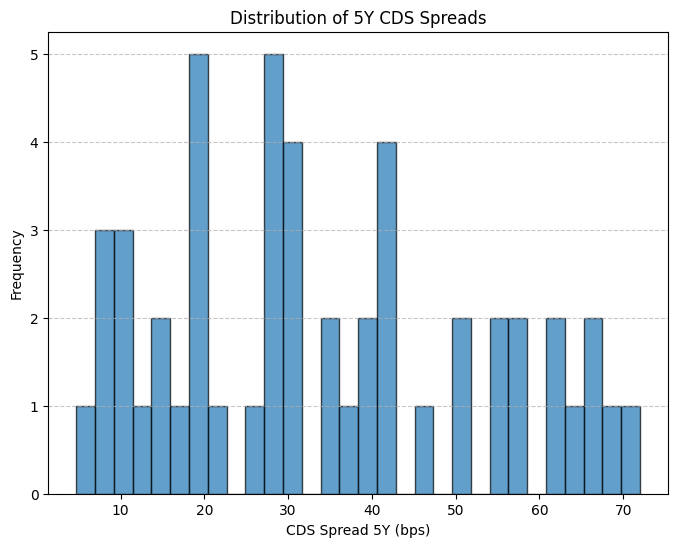

In [223]:
plt.figure(figsize=(8,6))
plt.hist(companies_data['CDS_Spread_5Y'], bins=30, edgecolor="black", alpha=0.7)

plt.xlabel("CDS Spread 5Y (bps)")
plt.ylabel("Frequency")
plt.title("Distribution of 5Y CDS Spreads")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()


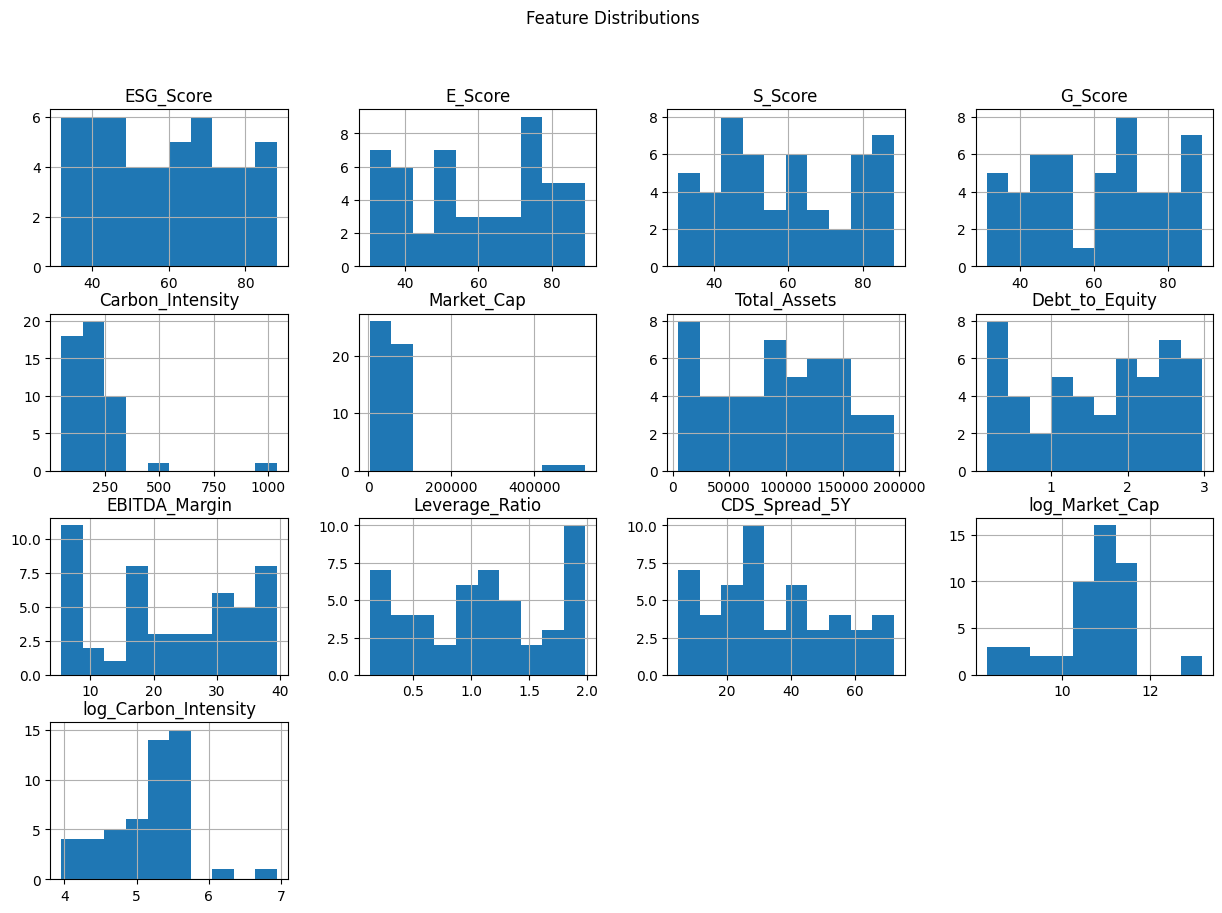

In [224]:
numeric_cols = companies_data.select_dtypes(include='number').columns

# Histograms of all the features
companies_data[numeric_cols].hist(bins=10, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.show()

### Implementation of linear regression model



In [225]:
# save the dataset used for the linear regression
linear_df = companies_data.copy()

# select numerical covariates
X_ols = linear_df[["ESG_Score", "Total_Assets", "Leverage_Ratio", "EBITDA_Margin"]]
X_ols = sm.add_constant(X_ols)  # add intercept

# define dependant variable
y = linear_df["CDS_Spread_5Y"]

# OLS REGRESSION
ols = sm.OLS(y, X_ols, missing="drop").fit()

# White’s heteroskedasticity-consistent SEs
ols_white = ols.get_robustcov_results(cov_type="HC0")   # HC0 = White
print(ols_white.summary())

# Jarque-Bera -> If p is small, residuals deviate from normality
# Durbin watson -> checks for autocorrelation, but this is not a time series

# should be zero
print(float(ols.resid.mean()))


                            OLS Regression Results                            
Dep. Variable:          CDS_Spread_5Y   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                     1.325
Date:                Thu, 02 Oct 2025   Prob (F-statistic):              0.275
Time:                        19:07:13   Log-Likelihood:                -216.01
No. Observations:                  50   AIC:                             442.0
Df Residuals:                      45   BIC:                             451.6
Df Model:                           4                                         
Covariance Type:                  HC0                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             17.8903     14.060      1.

R²:  0.075
RMSE: 18.20
MAE:  14.79

Cross-validated performance (5-fold, OLS via sklearn):
R²:   -0.123 ± 0.072
RMSE: 19.61 ± 1.64
MAE:  15.95 ± 1.36


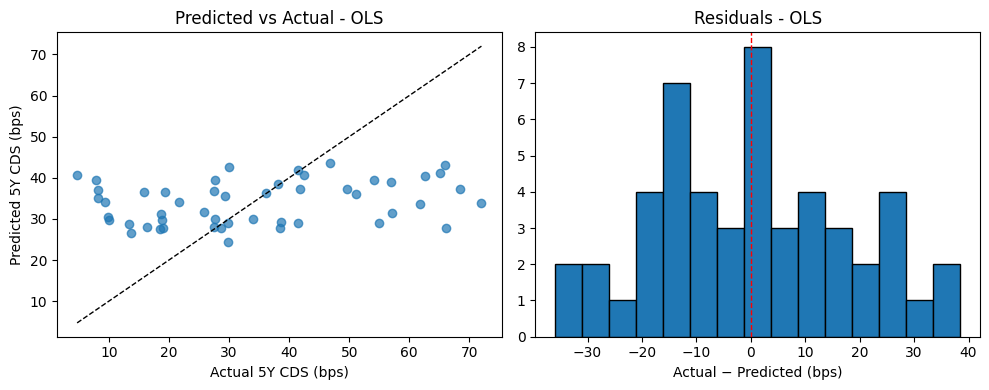

In [226]:
# In-sample metrics
y_pred = ols.predict(X_ols)
print(f"R²:  {r2_score(y, y_pred):.3f}")
print(f"RMSE: {mean_squared_error(y, y_pred)**0.5:.2f}")
print(f"MAE:  {mean_absolute_error(y, y_pred):.2f}")

# drop rows with any NaNs in X or y and align indices
valid_idx = X_ols.join(y).dropna().index
X_cv = X_ols.loc[valid_idx]
y_cv = y.loc[valid_idx]

# ---- Cross-validated performance using sklearn LinearRegression ----
# Note: sklearn adds its own intercept; use X_cv without the constant
lin = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Drop the constant column for sklearn's LinearRegression
X_cv_no_const = X_cv.drop(columns='const')

cv_r2   = cross_val_score(lin, X_cv_no_const, y_cv, cv=cv, scoring="r2")
cv_rmse = -cross_val_score(lin, X_cv_no_const, y_cv, cv=cv, scoring="neg_root_mean_squared_error")
cv_mae  = -cross_val_score(lin, X_cv_no_const, y_cv, cv=cv, scoring="neg_mean_absolute_error")

print("\nCross-validated performance (5-fold, OLS via sklearn):")
print(f"R²:   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"MAE:  {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")


# PLOTS
plt.figure(figsize=(10,4))
# Pred vs Actual
plt.subplot(1,2,1)
plt.scatter(y, y_pred, alpha=0.7)
lo_ols, hi_ols = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
plt.plot([lo_ols, hi_ols], [lo_ols, hi_ols], 'k--', lw=1)
plt.xlabel("Actual 5Y CDS (bps)"); plt.ylabel("Predicted 5Y CDS (bps)")
plt.title("Predicted vs Actual - OLS")

# Residuals
plt.subplot(1,2,2)
plt.hist( y - y_pred, bins=15, edgecolor="black")
plt.axvline(0, color="r", linestyle="--", lw=1)
plt.xlabel("Actual − Predicted (bps)"); plt.title("Residuals - OLS")
plt.tight_layout(); plt.show()

###Implementation of random forest


Top Features:
             Feature  Importance
      log_Market_Cap    0.381562
      Leverage_Ratio    0.204470
       EBITDA_Margin    0.176490
log_Carbon_Intensity    0.102907
           ESG_Score    0.094320
      Sector_Finance    0.011401
   Sector_Technology    0.009610
       Region_Europe    0.007858
Region_South America    0.006682
   Sector_Healthcare    0.002806
Region_North America    0.001893
       Sector_Energy    0.000000
  Sector_Industrials    0.000000
    Sector_Utilities    0.000000

Cross-validated performance (5-fold):
R²:   -0.073 ± 0.161
RMSE: 19.04 ± 1.14
MAE:  15.63 ± 0.56

OOS (cross_val_predict):
R²:   -0.017
RMSE: 19.08
MAE:  15.63


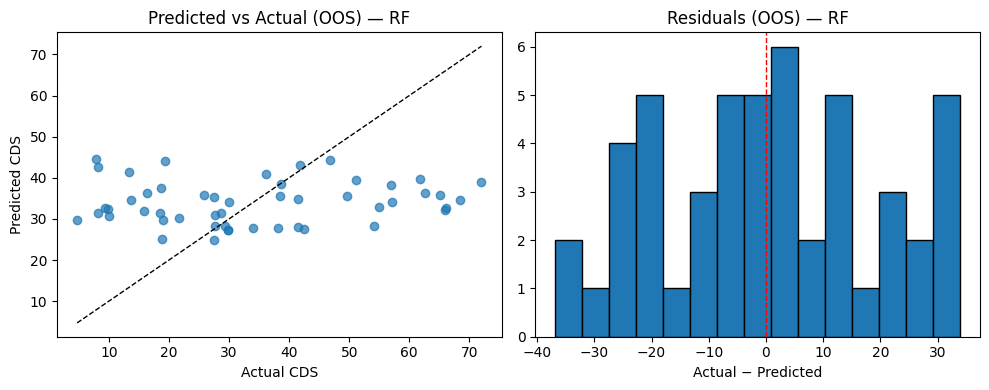

In [227]:
df_rf = companies_data.copy()

# One-hot encode sector/region
dummies_rf = pd.get_dummies(df_rf[["Sector", "Region"]], drop_first=True, dtype=float)

base_features_rf = [
    "ESG_Score",
    "log_Carbon_Intensity",
    "Leverage_Ratio",
    "log_Market_Cap",
    "EBITDA_Margin",
] 


X_rf = pd.concat([df_rf[base_features_rf], dummies_rf], axis=1)
y_rf = df_rf["CDS_Spread_5Y"]
# ----- Fit RF on full data
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    max_features=0.6,
    min_samples_leaf=6
)
rf.fit(X_rf, y_rf)



# Feature importance (Gini-based)
feat_imp_rf = (
    pd.DataFrame({"Feature": X_rf.columns, "Importance": rf.feature_importances_})
      .sort_values("Importance", ascending=False)
)
print("\nTop Features:")
print(feat_imp_rf.to_string(index=False))

# ----- 5-fold out-of-sample CV -----
cv_rf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_rf   = cross_val_score(rf, X_rf, y_rf, cv=cv_rf, scoring="r2", n_jobs=-1)
cv_rmse_rf = -cross_val_score(rf, X_rf, y_rf, cv=cv_rf,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_mae_rf  = -cross_val_score(rf, X_rf, y_rf, cv=cv_rf,
                              scoring="neg_mean_absolute_error", n_jobs=-1)

print("\nCross-validated performance (5-fold):")
print(f"R²:   {cv_r2_rf.mean():.3f} ± {cv_r2_rf.std():.3f}")
print(f"RMSE: {cv_rmse_rf.mean():.2f} ± {cv_rmse_rf.std():.2f}")
print(f"MAE:  {cv_mae_rf.mean():.2f} ± {cv_mae_rf.std():.2f}")
''' You can run it but it is slow
# ----- Permutation importance (on the full-data fitted model) -----
perm_rf = permutation_importance(
    rf, X_rf, y_rf, n_repeats=50, random_state=42, n_jobs=-1
)
perm_imp_rf = (
    pd.DataFrame({
        "Feature": X_rf.columns,
        "PermImportance": perm_rf.importances_mean,
        "PermStd": perm_rf.importances_std
    })
    .sort_values("PermImportance", ascending=False)
)
print("\nPermutation Importance (mean ± std):")
print(perm_imp_rf.to_string(index=False))
'''
# ----- Diagnostics: Predicted vs Actual & Residuals (using full-data model on X_rf) -----

# ---- OOS predictions aligned with your 5-fold CV ----
y_pred_oos_rf = cross_val_predict(rf, X_rf, y_rf, cv=cv_rf, n_jobs=-1)

print("\nOOS (cross_val_predict):")
print(f"R²:   {r2_score(y_rf, y_pred_oos_rf):.3f}")
print(f"RMSE: {mean_squared_error(y_rf, y_pred_oos_rf)**0.5:.2f}")
print(f"MAE:  {mean_absolute_error(y_rf, y_pred_oos_rf):.2f}")

# ---- OOS diagnostics
resid_oos = y_rf - y_pred_oos_rf
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(y_rf, y_pred_oos_rf, alpha=0.7)
lo, hi = min(y_rf.min(), y_pred_oos_rf.min()), max(y_rf.max(), y_pred_oos_rf.max())
plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
plt.xlabel("Actual CDS"); plt.ylabel("Predicted CDS")
plt.title("Predicted vs Actual (OOS) — RF")

plt.subplot(1,2,2)
plt.hist(resid_oos, bins=15, edgecolor="black")
plt.axvline(0, color="r", linestyle="--", lw=1)
plt.xlabel("Actual − Predicted"); plt.title("Residuals (OOS) — RF")
plt.tight_layout(); plt.show()



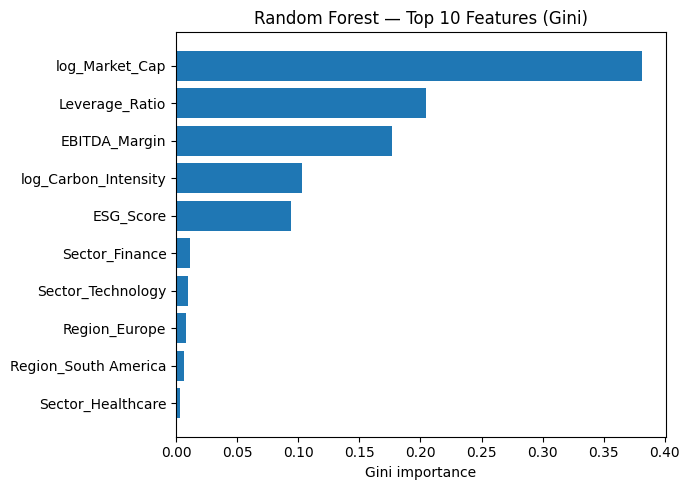

In [228]:
#  Gini importance — bar plot ===

top_n = 10
gini_top = feat_imp_rf.sort_values("Importance", ascending=False).head(top_n).iloc[::-1]

plt.figure(figsize=(7,5))
plt.barh(gini_top["Feature"], gini_top["Importance"])
plt.xlabel("Gini importance")
plt.title(f"Random Forest — Top {top_n} Features (Gini)")
plt.tight_layout()
plt.show()



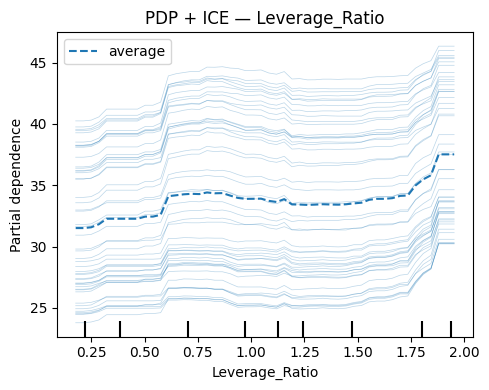

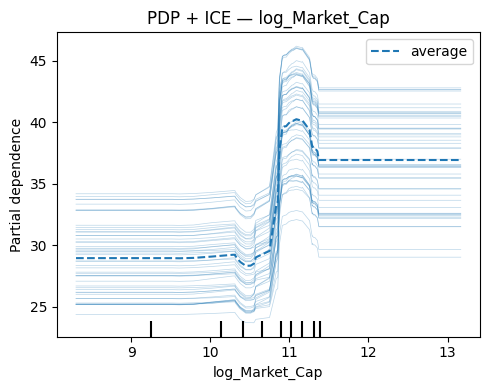

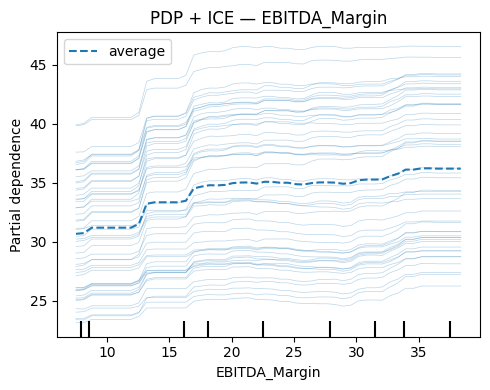

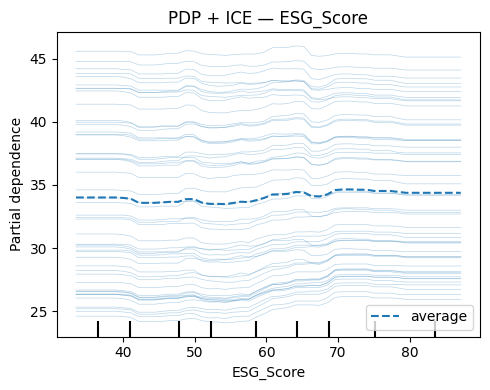

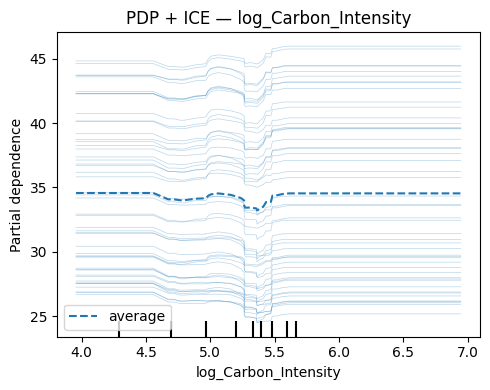

In [229]:
# Ensure model is fitted (safe to refit)
rf.fit(X_rf, y_rf)

features_to_plot = [
    "Leverage_Ratio",
    "log_Market_Cap",
    "EBITDA_Margin",
    "ESG_Score",
    "log_Carbon_Intensity",
]

for feat in features_to_plot:
    fig, ax = plt.subplots(figsize=(5,4))
    PartialDependenceDisplay.from_estimator(
        rf, X_rf,
        features=[feat],
        kind="both",                 # average PDP + ICE lines
        percentiles=(0.05, 0.95),    # trim outliers
        grid_resolution=50,
        ax=ax
    )
    ax.set_xlabel(feat)
    ax.set_ylabel("Predicted 5Y CDS (bps)")
    ax.set_title(f"PDP + ICE — {feat}")
    plt.tight_layout()
    plt.savefig(f"pdp_{feat}.png", dpi=200)   # saved for slides
    plt.show()




### Implementation of Gradient Boosting


Top Features (GB):
             Feature  Importance
      log_Market_Cap    0.372166
      Leverage_Ratio    0.290955
log_Carbon_Intensity    0.132035
       EBITDA_Margin    0.121550
           ESG_Score    0.032042
Region_North America    0.030034
Region_South America    0.017013
      Sector_Finance    0.003763
   Sector_Technology    0.000441
       Sector_Energy    0.000000
  Sector_Industrials    0.000000
   Sector_Healthcare    0.000000
       Region_Europe    0.000000
    Sector_Utilities    0.000000

Cross-validated performance (5-fold) — GB:
R²:   -0.325 ± 0.420
RMSE: 20.77 ± 2.18
MAE:  16.49 ± 2.05

OOS (cross_val_predict) — GB:
R²:   -0.219
RMSE: 20.89
MAE:  16.49


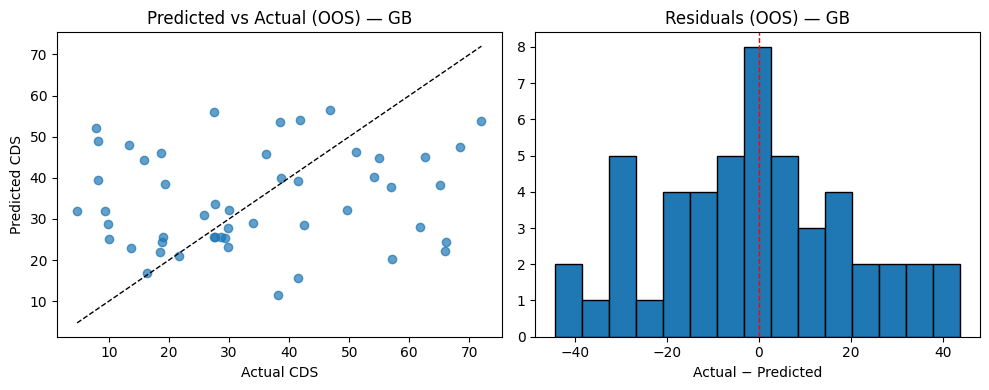

In [230]:

# Copy the data
df_gb = companies_data.copy()

# One-hot encode sector/region
dummies_gb = pd.get_dummies(df_gb[["Sector", "Region"]], drop_first=True, dtype=float)

base_features_gb = [
    "ESG_Score",
    "log_Carbon_Intensity",
    "Leverage_Ratio",
    "log_Market_Cap",
    "EBITDA_Margin",
]

X_gb = pd.concat([df_gb[base_features_gb], dummies_gb], axis=1)
y_gb = df_gb["CDS_Spread_5Y"].astype(float)

# ===== Fit GB on full data (for in-sample importances) =====
gb = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.01,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42,
)
gb.fit(X_gb, y_gb)

# Feature importance (GB)
feat_imp_gb = (
    pd.DataFrame({"Feature": X_gb.columns, "Importance": gb.feature_importances_})
      .sort_values("Importance", ascending=False)
)
print("\nTop Features (GB):")
print(feat_imp_gb.to_string(index=False))

# ===== 5-fold out-of-sample CV =====
cv_gb = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_gb   = cross_val_score(gb, X_gb, y_gb, cv=cv_gb, scoring="r2", n_jobs=-1)
cv_rmse_gb = -cross_val_score(gb, X_gb, y_gb, cv=cv_gb,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_mae_gb  = -cross_val_score(gb, X_gb, y_gb, cv=cv_gb,
                              scoring="neg_mean_absolute_error", n_jobs=-1)

print("\nCross-validated performance (5-fold) — GB:")
print(f"R²:   {cv_r2_gb.mean():.3f} ± {cv_r2_gb.std():.3f}")
print(f"RMSE: {cv_rmse_gb.mean():.2f} ± {cv_rmse_gb.std():.2f}")
print(f"MAE:  {cv_mae_gb.mean():.2f} ± {cv_mae_gb.std():.2f}")
'''
# ===== Permutation importance (on the full-data fitted model) =====
perm_gb = permutation_importance(
    gb, X_gb, y_gb, n_repeats=50, random_state=42, n_jobs=-1
)
perm_imp_gb = (
    pd.DataFrame({
        "Feature": X_gb.columns,
        "PermImportance": perm_gb.importances_mean,
        "PermStd": perm_gb.importances_std
    })
    .sort_values("PermImportance", ascending=False)
)
print("\nPermutation Importance (mean ± std) — GB:")
print(perm_imp_gb.to_string(index=False))
'''
# ===== OOS predictions aligned with 5-fold CV =====
y_pred_oos_gb = cross_val_predict(gb, X_gb, y_gb, cv=cv_gb, n_jobs=-1)

print("\nOOS (cross_val_predict) — GB:")
print(f"R²:   {r2_score(y_gb, y_pred_oos_gb):.3f}")
print(f"RMSE: {mean_squared_error(y_gb, y_pred_oos_gb)**0.5:.2f}")
print(f"MAE:  {mean_absolute_error(y_gb, y_pred_oos_gb):.2f}")

# ===== OOS diagnostics =====
resid_oos_gb = y_gb - y_pred_oos_gb
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(y_gb, y_pred_oos_gb, alpha=0.7)
lo_gb, hi_gb = min(y_gb.min(), y_pred_oos_gb.min()), max(y_gb.max(), y_pred_oos_gb.max())
plt.plot([lo_gb, hi_gb], [lo_gb, hi_gb], 'k--', lw=1)
plt.xlabel("Actual CDS"); plt.ylabel("Predicted CDS")
plt.title("Predicted vs Actual (OOS) — GB")

plt.subplot(1,2,2)
plt.hist(resid_oos_gb, bins=15, edgecolor="black")
plt.axvline(0, color="r", linestyle="--", lw=1)
plt.xlabel("Actual − Predicted"); plt.title("Residuals (OOS) — GB")
plt.tight_layout(); plt.show()


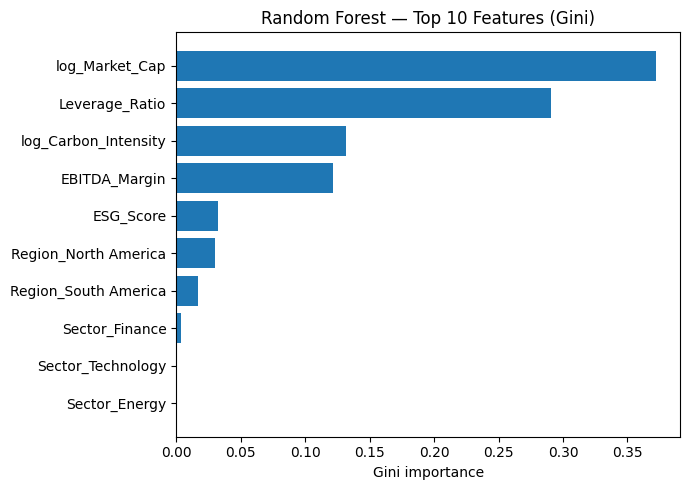

In [231]:
#  Gini importance — bar plot ===


top_n = 10
gini_top = feat_imp_gb.sort_values("Importance", ascending=False).head(top_n).iloc[::-1]

plt.figure(figsize=(7,5))
plt.barh(gini_top["Feature"], gini_top["Importance"])
plt.xlabel("Gini importance")
plt.title(f"Random Forest — Top {top_n} Features (Gini)")
plt.tight_layout()
plt.show()



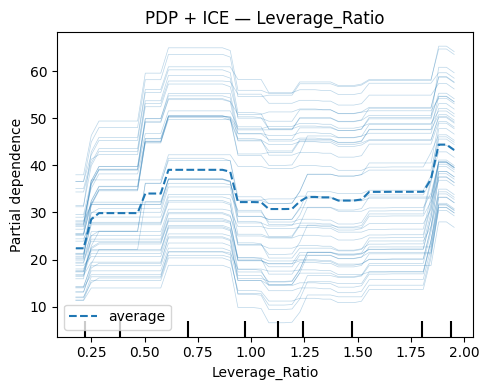

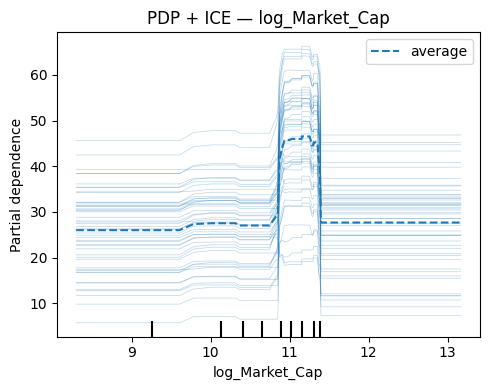

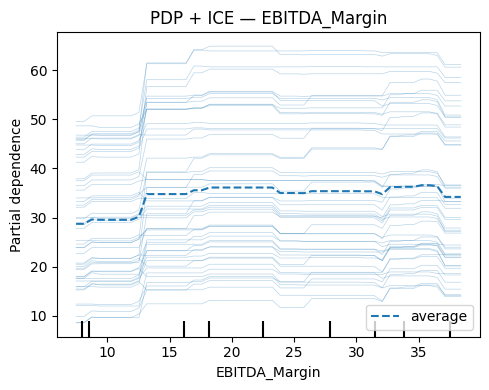

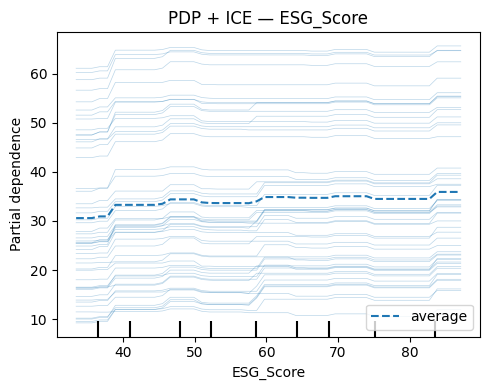

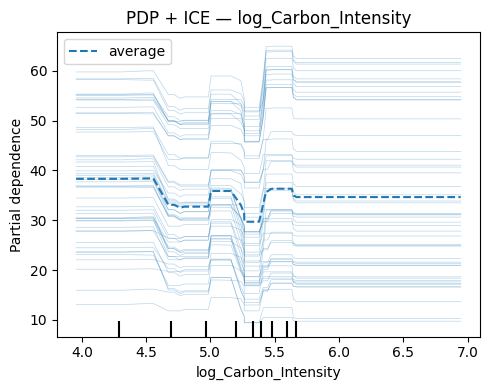

In [232]:


# Ensure model is fitted (safe to refit)
gb.fit(X_gb, y_gb)

features_to_plot = [
    "Leverage_Ratio",
    "log_Market_Cap",
    "EBITDA_Margin",
    "ESG_Score",
    "log_Carbon_Intensity",
]

for feat in features_to_plot:
    fig, ax = plt.subplots(figsize=(5,4))
    PartialDependenceDisplay.from_estimator(
        gb, X_gb,
        features=[feat],
        kind="both",                 # average PDP + ICE lines
        percentiles=(0.05, 0.95),    # trim outliers
        grid_resolution=50,
        ax=ax
    )
    ax.set_xlabel(feat)
    ax.set_ylabel("Predicted 5Y CDS (bps)")
    ax.set_title(f"PDP + ICE — {feat}")
    plt.tight_layout()
    plt.savefig(f"pdp_{feat}.png", dpi=200)   # saved for slides
    plt.show()




### From spreads to CVA

In [233]:
def _interp_zero_rate(t, zero_df=ZERO_RATES_DF):
    """
    Piecewise-linear interpolation of the zero rate (decimal) at time t (years).
    Clamps to the ends outside the curve.
    """
    # Clean the 'Zero_Rate' column: remove '%' and convert to float
    zero_df['Zero_Rate'] = zero_df['Zero_Rate'].astype(str).str.replace('%', '').astype(float) / 100.0

    x = zero_df.index.to_numpy(dtype=float)
    y = zero_df["Zero_Rate"].to_numpy(dtype=float)
    t_arr = np.atleast_1d(np.asarray(t, dtype=float))
    r = np.interp(t_arr, x, y, left=y[0], right=y[-1])
    return r if r.size > 1 else float(r)

def _discount_factor(t, zero_df=ZERO_RATES_DF, compounding="cont"):
    """
    Discount factor DF(t) from interpolated zero rates.
    compounding: 'cont' (exp(-r t)) or 'annual' ((1+r)^(-t))
    """
    t_arr = np.atleast_1d(np.asarray(t, dtype=float))
    r = _interp_zero_rate(t_arr, zero_df)
    if compounding == "cont":
        df = np.exp(-r * t_arr)
    elif compounding == "annual":
        df = (1.0 + r) ** (-t_arr)
    else:
        raise ValueError("compounding must be 'cont' or 'annual'")
    return df if df.size > 1 else float(df)

def compute_cva(cds_spread, recovery=0.40,
                ee_df=EE_PROFILE_DF, zero_df=ZERO_RATES_DF,
                compounding="cont"):
    """
    Discrete CVA:
        CVA ≈ LGD * sum_i EE_i * DF_i * (S_{i-1} - S_i),
        with S(t) = exp(-λ t), λ = spread / LGD  (spread in decimal p.a.)
    Args
    ----
    cds_spread : float | list[float] | np.ndarray
        CDS spread(s) in bps
    recovery : float
        Recovery rate R in [0,1]. LGD = 1 - R.
    ee_df : pd.DataFrame
        Must have index ['Year'] and columns ['EE'] (floats).
    zero_df : pd.DataFrame
        Must have index ['Maturity'] and columns ['Zero_Rate'] (zero rates as decimals).
    compounding : {'cont', 'annual'}
        Compounding convention for discount factors.

    Returns
    -------
    float or np.ndarray
        CVA for each input spread. (Same shape as input spreads.)
    """
    lgd = 1.0 - recovery

    # Grid from EE profile
    t = ee_df.index.to_numpy(dtype=float)             # t_i
    EE = ee_df["EE"].to_numpy(dtype=float)              # EE_i
    DF = _discount_factor(t, zero_df, compounding)      # DF_i at t_i

    # Spreads (bps) -> decimal per annum
    spreads_dec = np.atleast_1d(np.asarray(cds_spread, dtype=float)) / 1e4

    # Spreads -> hazard λ via λ = spread / LGD (spread in decimal p.a.)
    lambdas = spreads_dec / lgd

    # Survival differences per interval: S(t_{i-1}) - S(t_i)
    t_prev = np.concatenate([[0.0], t[:-1]])
    t_curr = t

    # Build matrix of (S_{i-1} - S_i) for each lambda (vectorized)
    surv_diff = np.exp(-np.outer(lambdas, t_prev)) - np.exp(-np.outer(lambdas, t_curr))  # shape (#λ, N)

    # Sum across i
    contrib = EE * DF  # length N
    cva_vals = lgd * (surv_diff @ contrib)  # shape (#λ,)

    return cva_vals

cva_true = compute_cva(companies_data["CDS_Spread_5Y"], recovery=0.40)
cva_true

array([ 8589.71277063,  9628.74463463, 15453.66755911,  7574.71589588,
        7003.80980367, 16279.27658993,  4714.41119463,  6958.55635934,
        2085.44851849,  7559.21181596,  9707.31221752,  9115.16816596,
        2068.32612449,  1997.1864716 , 16484.62046077, 17965.92281253,
       13779.60722661,  5512.47453819,  4799.00646715, 13570.20240823,
        6542.9750639 , 11789.32196726,  3489.79140825,  4900.63262877,
        2384.00421279, 10440.29811865,  9732.5430961 , 14277.05674939,
       17098.44361279,  3411.77148619,  4735.95913248,  1203.83845531,
        2517.32434727, 10444.52434651,  4805.46451889,  4023.20825492,
        4158.57069918, 12859.46195072, 10688.67136464, 14309.12392402,
        2542.77511159,  6995.9836452 , 16525.06419927,  7556.00572483,
        7440.61878731, 12460.3939956 , 15672.65273377,  7236.8913151 ,
       10544.59773169,  6947.89443728])

In [ ]:
cva_gb=compute_cva(y_pred_oos_gb, recovery=0.40)
cva_rf=compute_cva(y_pred_oos_rf, recovery=0.40)

### Compute the Green Premium

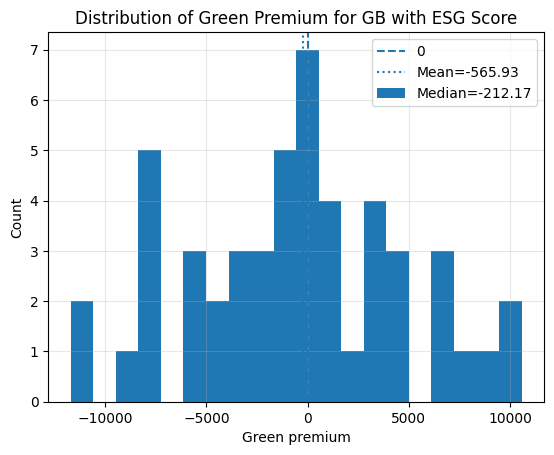

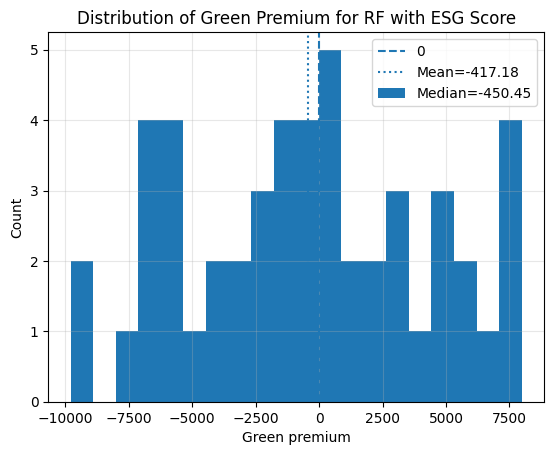

Text(0.5, 0, 'Green premium')

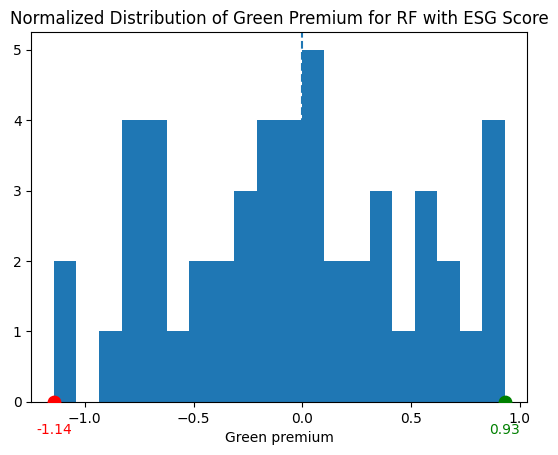

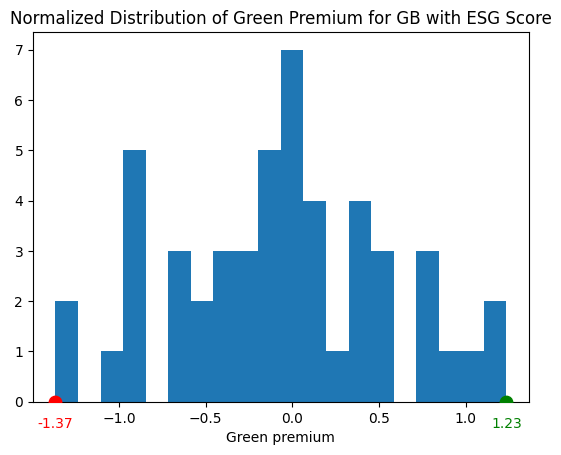

In [ ]:

# 0) Build a clean Series
green_premium_rf = pd.Series(cva_true- cva_rf, name="Green_premium").astype(float)
green_premium_rf = green_premium_rf.replace([np.inf, -np.inf], np.nan).dropna()
green_premium_gb = pd.Series(cva_true- cva_gb, name="Green_premium").astype(float)
green_premium_gb = green_premium_gb.replace([np.inf, -np.inf], np.nan).dropna()

#  Distribution (histogram) with mean/median lines for gradient boosting with ESG_SCORE
plt.figure()
plt.hist(green_premium_gb.values, bins=20)
plt.axvline(0, linestyle="--")
plt.axvline(green_premium_gb.median(), linestyle=":")
plt.title("Distribution of Green Premium for GB with ESG Score")
plt.xlabel("Green premium")
plt.ylabel("Count")
plt.legend(["0", f"Mean={green_premium_gb.mean():.2f}", f"Median={green_premium_gb.median():.2f}"])
plt.grid(True, alpha=0.3)
plt.show()


#  Distribution (histogram) with mean/median lines for random forest with ESG_SCORE
plt.figure()
plt.hist(green_premium_rf.values, bins=20)
plt.axvline(0, linestyle="--")
plt.axvline(green_premium_rf.median(), linestyle=":")
plt.title("Distribution of Green Premium for RF with ESG Score")
plt.xlabel("Green premium")
plt.ylabel("Count")
plt.legend(["0", f"Mean={green_premium_rf.mean():.2f}", f"Median={green_premium_rf.median():.2f}"])
plt.grid(True, alpha=0.3)
plt.show()

#how big the model’s error is compared to the average CVA level.

#  Distribution (histogram) with mean/median lines for random forest with ESG_SCORE
normalized_green_premium_rf=green_premium_rf.values/np.average(cva_true)
min_val_rf = np.min(normalized_green_premium_rf)
max_val_rf= np.max(normalized_green_premium_rf)
plt.figure()
# Mark min and max as points on x-axis
plt.scatter(min_val_rf, 0, color="red", s=80, label=f"Min: {min_val_rf:.2f}", zorder=5)
plt.scatter(max_val_rf, 0, color="green", s=80, label=f"Max: {max_val_rf:.2f}", zorder=5)
# Add number labels right at x-axis
plt.text(min_val_rf, -0.3, f"{min_val_rf:.2f}", color="red", ha="center", va="top")
plt.text(max_val_rf, -0.3, f"{max_val_rf:.2f}", color="green", ha="center", va="top")

plt.hist(normalized_green_premium_rf, bins=20)
plt.axvline(0, linestyle="--")
plt.title("Normalized Distribution of Green Premium for RF with ESG Score")
plt.xlabel("Green premium")


#  Distribution (histogram) with mean/median lines for random forest with ESG_SCORE
normalized_green_premium_gb=green_premium_gb.values/np.average(cva_true)
min_val_gb = np.min(normalized_green_premium_gb)
max_val_gb= np.max(normalized_green_premium_gb)
plt.figure()
# Mark min and max as points on x-axis
plt.scatter(min_val_gb, 0, color="red", s=80, label=f"Min: {min_val_gb:.2f}", zorder=5)
plt.scatter(max_val_gb, 0, color="green", s=80, label=f"Max: {max_val_gb:.2f}", zorder=5)
# Add number labels right at x-axis
plt.text(min_val_gb, -0.3, f"{min_val_gb:.2f}", color="red", ha="center", va="top")
plt.text(max_val_gb, -0.3, f"{max_val_gb:.2f}", color="green", ha="center", va="top")
plt.hist(normalized_green_premium_gb, bins=20)
plt.title("Normalized Distribution of Green Premium for GB with ESG Score")
plt.xlabel("Green premium")



In [236]:
# Create a DataFrame with the desired columns
results_table = companies_data[["Company", "CDS_Spread_5Y"]].copy()
results_table["CDS_Predicted_GB"] = y_pred_oos_gb
results_table["CDS_Predicted_RF"] = y_pred_oos_rf
# Add  CVA
results_table["CVA_Actual"] = cva_true
results_table["CVA_Predicted_GB"] = cva_gb
results_table["CVA_Predicted_RF"] = cva_rf
# Add predicted CDS and CVA from Gradient Boosting
results_table["Green_Premium_GB"] = cva_true-cva_gb
results_table["Green_Premium_RF"] =  cva_true-cva_rf
# Add predicted CDS and CVA from Random Forest



# Display the results table
display(results_table)

,Company,CDS_Spread_5Y,CDS_Predicted_GB,CDS_Predicted_RF,CVA_Actual,CVA_Predicted_GB,CVA_Predicted_RF,Green_Premium_GB,Green_Premium_RF
1,Company_1,34.0068,28.939593,27.775542,8589.712771,7675.969848,7373.575375,913.742923,1216.137396
2,Company_3,38.1718,11.475476,27.803938,9628.744635,3061.454235,7381.044344,6567.290399,2247.700290
3,Company_4,61.7321,27.975404,39.670301,15453.667559,7422.597907,10489.883382,8031.069653,4963.784178
4,Company_5,29.9490,32.280645,34.114978,7574.715896,8552.684959,9037.507880,-977.969063,-1462.791984
5,Company_6,27.6713,25.638762,28.178767,7003.809804,6807.896262,7479.619935,195.913542,-475.810132
6,Company_7,65.1008,38.129182,35.737844,16279.276590,10082.706948,9462.341670,6196.569642,6816.934920
7,Company_8,18.5712,21.944021,31.383275,4714.411195,5833.968993,8321.367902,-1119.557799,-3606.956707
8,Company_9,27.4909,55.889070,35.227067,6958.556359,14692.603054,9328.679751,-7734.046694,-2370.123391
9,Company_10,8.1874,49.009085,42.688538,2085.448518,12913.220931,11276.724303,-10827.772413,-9191.275785
10,Company_11,29.8871,23.077533,27.249493,7559.211816,6133.015067,7235.186462,1426.196749,324.025354


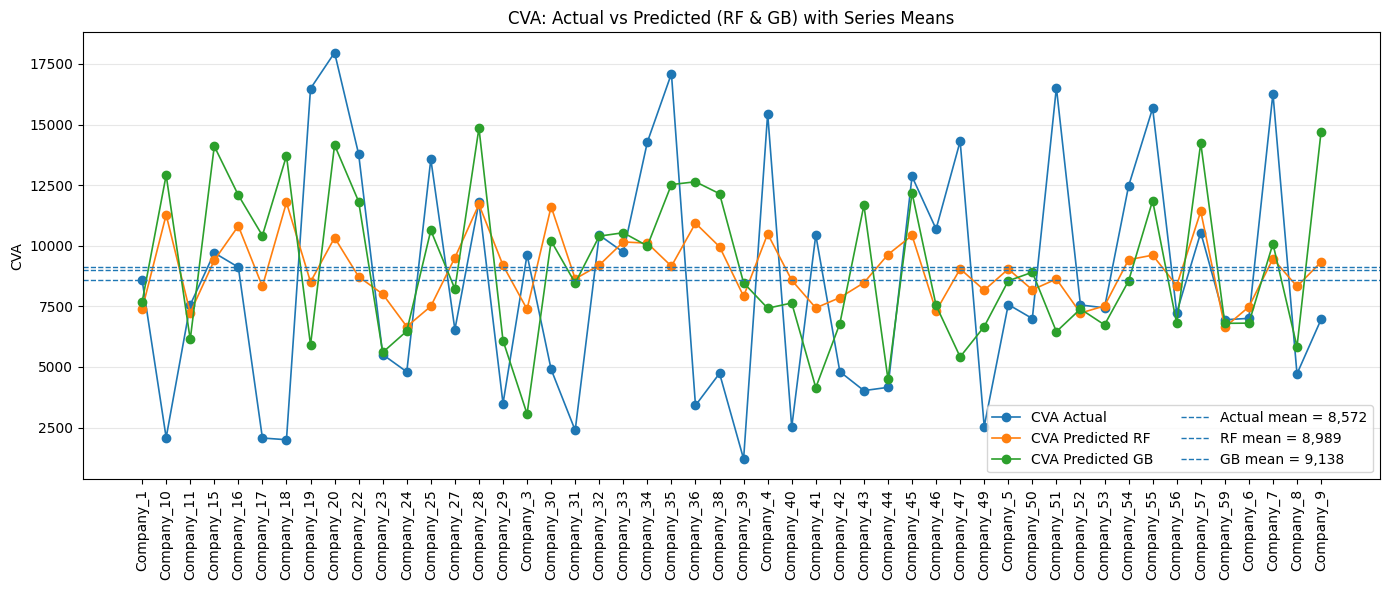

In [ ]:

# Prep
df = results_table.copy()
cols = ["CVA_Actual", "CVA_Predicted_RF", "CVA_Predicted_GB"]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=cols).sort_values("Company").reset_index(drop=True)

x = np.arange(len(df))

# Plot series
plt.figure(figsize=(14,6))
plt.plot(x, df["CVA_Actual"].values, marker="o", linewidth=1.2, label="CVA Actual")
plt.plot(x, df["CVA_Predicted_RF"].values, marker="o", linewidth=1.2, label="CVA Predicted RF")
plt.plot(x, df["CVA_Predicted_GB"].values, marker="o", linewidth=1.2, label="CVA Predicted GB")

# Means (horizontal lines)
m_act = df["CVA_Actual"].mean()
m_rf  = df["CVA_Predicted_RF"].mean()
m_gb  = df["CVA_Predicted_GB"].mean()

plt.axhline(m_act, linestyle="--", linewidth=1, label=f"Actual mean = {m_act:,.0f}")
plt.axhline(m_rf,  linestyle="--", linewidth=1, label=f"RF mean = {m_rf:,.0f}")
plt.axhline(m_gb,  linestyle="--", linewidth=1, label=f"GB mean = {m_gb:,.0f}")

# Cosmetics
plt.xticks(x, df["Company"], rotation=90)
plt.ylabel("CVA")
plt.title("CVA: Actual vs Predicted (RF & GB) with Series Means")
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


C:\Users\alans\AppData\Local\Temp\ipykernel_6636\1934529376.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tert, g in df.groupby("ESG_tertile"):


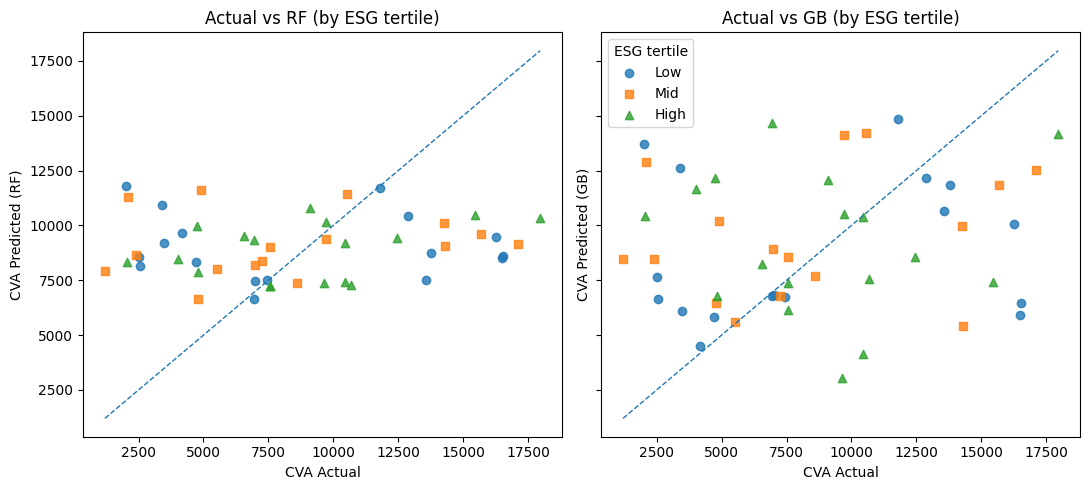

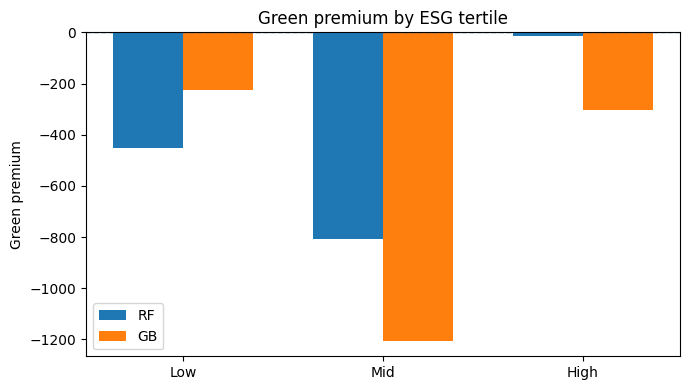

In [ ]:


# --- Merge ESG_Score into results_table ---
# Works whether your base DF is named company_data or companies_data

src = companies_data

df = results_table.merge(src[["Company","ESG_Score"]], on="Company", how="left").dropna(subset=["ESG_Score","CVA_Actual"])

# ESG tertiles (robust to ties)
try:
    df["ESG_tertile"] = pd.qcut(df["ESG_Score"], 3, labels=["Low","Mid","High"], duplicates="drop")
except ValueError:
    df["ESG_tertile"] = pd.qcut(df["ESG_Score"], 2, labels=["Low","High"], duplicates="drop")

# Deltas vs Actual (market) CVA
df["DeltaCVA_RF"] =  df["CVA_Actual"]-df["CVA_Predicted_RF"]
df["DeltaCVA_GB"] =  df["CVA_Actual"]-df["CVA_Predicted_GB"]

# ----- 1) Actual vs Predicted (RF & GB), colored by ESG tertile -----
markers = {"Low":"o","Mid":"s","High":"^"}
fig, axes = plt.subplots(1, 2, figsize=(11,5), sharex=True, sharey=True)

for tert, g in df.groupby("ESG_tertile"):
    axes[0].scatter(g["CVA_Actual"], g["CVA_Predicted_RF"], alpha=0.8, marker=markers.get(str(tert),"o"), label=str(tert))
    axes[1].scatter(g["CVA_Actual"], g["CVA_Predicted_GB"], alpha=0.8, marker=markers.get(str(tert),"o"), label=str(tert))

# 45° reference lines
lo = df[["CVA_Actual","CVA_Predicted_RF","CVA_Predicted_GB"]].min().min()
hi = df[["CVA_Actual","CVA_Predicted_RF","CVA_Predicted_GB"]].max().max()
for ax in axes:
    ax.plot([lo,hi],[lo,hi],"--", linewidth=1)
    ax.set_xlabel("CVA Actual")
axes[0].set_ylabel("CVA Predicted (RF)")
axes[1].set_ylabel("CVA Predicted (GB)")
axes[0].set_title("Actual vs RF (by ESG tertile)")
axes[1].set_title("Actual vs GB (by ESG tertile)")
axes[1].legend(title="ESG tertile")
plt.tight_layout()
plt.show()

# ----- 2) Mean ΔCVA by ESG tertile (side-by-side bars) -----
tertiles = [t for t in ["Low","Mid","High"] if t in df["ESG_tertile"].astype(str).unique()]
grp = df.groupby("ESG_tertile", observed=True)
mean_rf = grp["DeltaCVA_RF"].mean().reindex(tertiles)
mean_gb = grp["DeltaCVA_GB"].mean().reindex(tertiles)

x = np.arange(len(tertiles))
w = 0.35

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x - w/2, mean_rf.values, width=w, label="RF")
ax.bar(x + w/2, mean_gb.values, width=w, label="GB")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(tertiles)
ax.set_ylabel("Green premium")
ax.set_title("Green premium by ESG tertile")
ax.legend()
plt.tight_layout()
plt.show()



#Extending dataset does not mean better results

Real rows: 50, Synthetic rows: 300, Total: 350

Top Features:
             Feature  Importance
      log_Market_Cap    0.326615
       EBITDA_Margin    0.249119
      Leverage_Ratio    0.213378
           ESG_Score    0.092530
log_Carbon_Intensity    0.081623
      Sector_Finance    0.014377
   Sector_Healthcare    0.005223
Region_North America    0.004480
       Sector_Energy    0.004147
       Region_Europe    0.003310
Region_South America    0.002575
   Sector_Technology    0.001904
  Sector_Industrials    0.000639
    Sector_Utilities    0.000081

Cross-validated performance (5-fold):
R²:   0.030 ± 0.165
RMSE: 17.54 ± 0.65
MAE:  14.54 ± 0.59

Permutation Importance (mean ± std):
             Feature  PermImportance  PermStd
      log_Market_Cap        0.288718 0.033677
       EBITDA_Margin        0.173510 0.020484
      Leverage_Ratio        0.121830 0.013961
           ESG_Score        0.033049 0.003781
log_Carbon_Intensity        0.030574 0.003618
      Sector_Finance        0.00

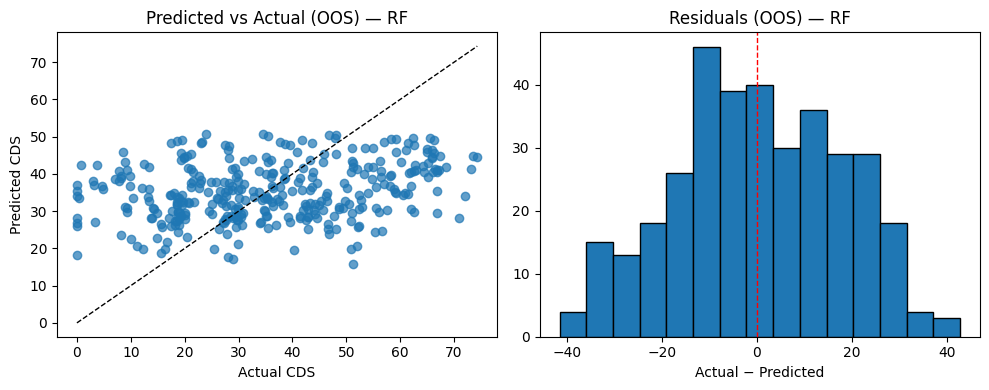

In [239]:
from sklearn.linear_model import Ridge

# ==== 1) Prepare base (real) data ====
num = ["ESG_Score","log_Market_Cap","log_Carbon_Intensity","Leverage_Ratio","EBITDA_Margin"]
cat = ["Sector","Region"]
cols = num + cat + ["CDS_Spread_5Y"]
df_base=companies_data.copy()


# Fit a quick baseline (for generating realistic y via prediction + residual)
X_real = pd.get_dummies(df_base[num + cat], drop_first=True, dtype=float)
y_real = df_base["CDS_Spread_5Y"].astype(float)
ridge = Ridge(alpha=1.0).fit(X_real, y_real)
resid_real = (y_real - ridge.predict(X_real)).reset_index(drop=True)

# Map residuals by sector (keeps sector-level dispersion)
res_map = {
    s: resid_real[df_base["Sector"].reset_index(drop=True) == s].values
    for s in df_base["Sector"].unique()
}

# ==== 2) Simple synthetic generator ====
def make_synth(train_df, n_new=0, jitter=0.10, rng=42):
    """
    Bootstrap rows, jitter numeric features, predict y with a simple model,
    then add a sampled residual from the same sector.
    """
    if n_new <= 0:
        n_new = len(train_df) * 3  # 3x augmentation by default
    rs = np.random.RandomState(rng)

    samp = train_df.sample(n=n_new, replace=True, random_state=rng).reset_index(drop=True)

    # jitter numeric columns (stay within observed min/max)
    for c in num:
        std = train_df[c].std(ddof=0)
        noise = rs.normal(0.0, jitter * (std if std > 0 else 1e-6), size=n_new)
        lo, hi = train_df[c].min(), train_df[c].max()
        samp[c] = np.clip(samp[c].astype(float) + noise, lo, hi)

    # predict y_hat, then add sector-specific residual
    Xs = pd.get_dummies(samp[num + cat], drop_first=True, dtype=float)
    Xs = Xs.reindex(columns=X_real.columns, fill_value=0)   # align columns
    y_hat = ridge.predict(Xs)

    res = np.array([rs.choice(res_map.get(sec, resid_real.values)) for sec in samp["Sector"]])
    y_syn = np.clip(y_hat + res, a_min=0, a_max=None)       # CDS ≥ 0
    samp["CDS_Spread_5Y"] = y_syn
    return samp[cols]

# ==== 3) Build augmented dataset ====
df_syn = make_synth(df_base, n_new=len(df_base)*6, jitter=0.10, rng=42)
df_aug = pd.concat([df_base, df_syn], ignore_index=True)

print(f"Real rows: {len(df_base)}, Synthetic rows: {len(df_syn)}, Total: {len(df_aug)}")
df_rf = df_aug.copy()
dummies_rf = pd.get_dummies(df_rf[["Sector","Region"]], drop_first=True, dtype=float)
base_features_rf = ["ESG_Score","log_Market_Cap","log_Carbon_Intensity","Leverage_Ratio","EBITDA_Margin"]
X_rf = pd.concat([df_rf[base_features_rf], dummies_rf], axis=1)
y_rf = df_rf["CDS_Spread_5Y"].astype(float)
# ... (keep your RF + CV + cross_val_predict exactly the same)


X_rf = pd.concat([df_rf[base_features_rf], dummies_rf], axis=1)
y_rf = df_rf["CDS_Spread_5Y"]
# ----- Fit RF on full data (for in-sample metrics & feature importances) -----
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=3,
    oob_score=True,
)
rf.fit(X_rf, y_rf)



# Feature importance (Gini-based)
feat_imp_rf = (
    pd.DataFrame({"Feature": X_rf.columns, "Importance": rf.feature_importances_})
      .sort_values("Importance", ascending=False)
)
print("\nTop Features:")
print(feat_imp_rf.to_string(index=False))

# ----- 5-fold out-of-sample CV -----
cv_rf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_rf   = cross_val_score(rf, X_rf, y_rf, cv=cv_rf, scoring="r2", n_jobs=-1)
cv_rmse_rf = -cross_val_score(rf, X_rf, y_rf, cv=cv_rf,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_mae_rf  = -cross_val_score(rf, X_rf, y_rf, cv=cv_rf,
                              scoring="neg_mean_absolute_error", n_jobs=-1)

print("\nCross-validated performance (5-fold):")
print(f"R²:   {cv_r2_rf.mean():.3f} ± {cv_r2_rf.std():.3f}")
print(f"RMSE: {cv_rmse_rf.mean():.2f} ± {cv_rmse_rf.std():.2f}")
print(f"MAE:  {cv_mae_rf.mean():.2f} ± {cv_mae_rf.std():.2f}")

# ----- Permutation importance (on the full-data fitted model) -----
perm_rf = permutation_importance(
    rf, X_rf, y_rf, n_repeats=50, random_state=42, n_jobs=-1
)
perm_imp_rf = (
    pd.DataFrame({
        "Feature": X_rf.columns,
        "PermImportance": perm_rf.importances_mean,
        "PermStd": perm_rf.importances_std
    })
    .sort_values("PermImportance", ascending=False)
)
print("\nPermutation Importance (mean ± std):")
print(perm_imp_rf.to_string(index=False))

# ----- Diagnostics: Predicted vs Actual & Residuals (using full-data model on X_rf) -----

# ---- OOS predictions aligned with your 5-fold CV ----
y_pred_oos = cross_val_predict(rf, X_rf, y_rf, cv=cv_rf, n_jobs=-1)

print("\nOOS (cross_val_predict):")
print(f"R²:   {r2_score(y_rf, y_pred_oos):.3f}")
print(f"RMSE: {mean_squared_error(y_rf, y_pred_oos)**0.5:.2f}")
print(f"MAE:  {mean_absolute_error(y_rf, y_pred_oos):.2f}")

# ---- OOS diagnostics
resid_oos = y_rf - y_pred_oos
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(y_rf, y_pred_oos, alpha=0.7)
lo, hi = min(y_rf.min(), y_pred_oos.min()), max(y_rf.max(), y_pred_oos.max())
plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
plt.xlabel("Actual CDS"); plt.ylabel("Predicted CDS")
plt.title("Predicted vs Actual (OOS) — RF")

plt.subplot(1,2,2)
plt.hist(resid_oos, bins=15, edgecolor="black")
plt.axvline(0, color="r", linestyle="--", lw=1)
plt.xlabel("Actual − Predicted"); plt.title("Residuals (OOS) — RF")
plt.tight_layout(); plt.show()
